# Stage 8: Clustering and Visualization

### Project Structure

```bash
CS5246Project/
    │
    ├─ data/
    │   ├─ inverted_index/
    │   │   ├─ inverted_index_tfidf_titles.json
    │   │   └─ inverted_index_tfidf_fulltext.json
    │   │
    │   ├─ models/
    │   │   ├─ sentence_bert_model/
    │   │   ├─ bm25_comments_model.joblib
    │   │   ├─ bm25_fulltext_model.joblib
    │   │   ├─ bm25_titles_model.joblib
    │   │   ├─ tfidf_comments_vectorizer.joblib
    │   │   └─ tfidf_posts_vectorizer.joblib
    │   │
    │   ├─ vector_database/
    │   │   ├─ bert_comments_embeddings.npy
    │   │   ├─ bert_contents_embeddings.npy
    │   │   ├─ bert_fulltext_embeddings.npy
    │   │   ├─ bert_titles_embeddings.npy
    │   │   ├─ bm25_comments.npz
    │   │   ├─ bm25_contents.npz
    │   │   ├─ bm25_fulltext.npz
    │   │   ├─ bm25_titles.npz
    │   │   ├─ tfidf_comments.npz
    │   │   ├─ tfidf_contents.npz
    │   │   ├─ tfidf_fulltext.npz
    │   │   └─ tfidf_titles.npz
    │   │
    │   ├─ PostVault.csv
    │   ├─ CommentVault.csv
    │   └─ raw_data/
    │    
    ├─ sentiment_plots/
    │   ├─ emotion_plots/
    │   ├─ emotion_dashboard.py
    │   └─ plot_emotion_summary.py
    │
    ├─ Stage_0_Introduction.ipynb                       
    ├─ Stage_1_Data_Collection_and_Data_Cleaning.ipynb
    ├─ Stage_2_POS_and_NER_Tagging.ipynb
    ├─ Stage_3_Singlish_Normalisation.ipynb
    ├─ Stage_4_Singlish_to_English_Conversion.ipynb     
    ├─ Stage_5_Common_Normalisation.ipynb
    ├─ Stage_6_Vector_Space_Model_and_Inverted_Index.ipynb      
    ├─ Stage_7_Sentiment_Analysis.ipynb
-----------------------------------------------------------------
│   ├─ Stage_8_Clustering_and_Visualization.ipynb               │
-----------------------------------------------------------------     
    ├─ Stage_9_Document_Search.ipynb
    └─ utilities/
        │
        ├─ pp_class.py
        ├─ singlish_dictionary.json
        ├─ singlish_regex_to_text.txt
        └─ slang_dictionary.csv
```

## To access the mounted folder directly.

### Step 1: Add the Shared Folder to your Google Drive (if you haven't already)

1.  **Open Google Drive** (drive.google.com) in your web browser.
2.  Go to the **'Shared with me'** section.
3.  Locate the folder that was shared with you.
4.  **Right-click** on the shared folder.
5.  Select **'Add shortcut to Drive'** (or 'Add to My Drive', depending on the interface). Choose a location within 'My Drive' if prompted, or simply add it to the root of 'My Drive'.

This creates a shortcut to the shared folder in your 'My Drive', making it accessible when Colab mounts your personal Drive.
### Step 2: Access the Shared Folder in Colab (No action needed)

Once your Drive is mounted, you can navigate to the shared folder. If you added a shortcut, it will appear in your 'My Drive' just like any other folder. The path will typically be `/content/gdrive/MyDrive/YourSharedFolderName`.

It should be able to run the script below already

In [ ]:
# -----------
# Mount Drive
# -----------
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dependencies

### Install Dependencies

In [ ]:
!pip install emoji ftfy langdetect import-ipynb matplotlib seaborn wordcloud rank_bm25

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 15.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.0 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f1856a51f7427ef4a191ede62c2e49e38a8d0eb023109de6f531de11893b4664
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


### Change Directory

In [ ]:
# Path
# ----
FOLDER_PATH: str = "/content/drive/MyDrive/CS5246Project/"

import os
os.chdir(FOLDER_PATH)

### Import Essential Library

In [ ]:
import os
import re
import json
import joblib
import numpy as np
import pandas as pd
import import_ipynb
import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from scipy.sparse import load_npz
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from Stage_2_POS_and_NER_Tagging import pos_tagger
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from Stage_0_Introduction import display_first_text_column_head, save_dfs_to_csv, output_base_dir, save_single_df_to_csv, vector_database_dir, models_dir, inverted_index_dir

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.5 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Clustering and Visualization

### Core Functions

#### K-Means

In [ ]:
def get_kmeans_labels(data, n_clusters=7, random_state=42):
    # Instantiate the KMeans model with 'auto' n_init for modern scikit-learn behavior
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')

    # Fit the model to the reduced TF-IDF data
    kmeans.fit(data)

    # Extract cluster labels
    labels = kmeans.labels_

    # Print execution summary for debugging/tracking
    print("-----------------------------------")
    print(f"K-Means Clustering (k={n_clusters}) Completed")
    print("-----------------------------------")
    print(f"Shape of cluster labels: {labels.shape}")
    print(f"First 10 labels: {labels[:10]}")

    return labels

# Usage:
# posts_cluster_labels = get_kmeans_labels(tfidf_posts_reduced)

#### t-SNE

In [ ]:
def perform_tsne(data, n_components=3, random_state=42, n_jobs=-1):
    # Initialize the TSNE model for 3D embedding
    tsne_model = TSNE(n_components=n_components, random_state=random_state, n_jobs=n_jobs)

    # Fit and transform the data
    tsne_results = tsne_model.fit_transform(data)

    # Print execution summary
    print("--------------------------------------------")
    print(f"t-SNE {n_components}D Dimensionality Reduction Completed")
    print("--------------------------------------------")
    print(f"Shape of tsne_results: {tsne_results.shape}")
    print(f"First 5 rows of tsne_results:\n{tsne_results[:5]}")

    return tsne_results

# Usage:
# posts_tsne_3d = perform_tsne(tfidf_posts_reduced)

#### Scatter Plot

In [ ]:
def plot_scatter(tsne_data, cluster_labels, title='t-SNE Visualization', figsize=(12, 10)):
    # Check dimensions (the last column count)
    dims = tsne_data.shape[1]

    fig = plt.figure(figsize=figsize)

    if dims == 3:
        # -----------------
        # 3D Plotting Logic
        # -----------------
        ax = fig.add_subplot(111, projection='3d')
        x, y, z = tsne_data[:, 0], tsne_data[:, 1], tsne_data[:, 2]

        scatter = ax.scatter(
            x, y, z,
            c=cluster_labels,
            cmap='tab10',
            s=6,
            alpha=0.7
        )
        ax.set_zlabel('t-SNE Dimension 3')

        # Set 3D limits
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(y.min(), y.max())
        ax.set_zlim(z.min(), z.max())

    elif dims == 2:
        # -----------------
        # 2D Plotting Logic
        # -----------------
        ax = fig.add_subplot(111)
        x, y = tsne_data[:, 0], tsne_data[:, 1]

        scatter = ax.scatter(
            x, y,
            c=cluster_labels,
            cmap='tab10',
            s=10, # Slightly larger points for 2D
            alpha=0.7
        )

        # Set 2D limits
        ax.set_xlim(x.min(), x.max())
        ax.set_ylim(y.min(), y.max())

    else:
        raise ValueError("The input data must have either 2 or 3 columns.")

    # Shared settings for both 2D and 3D
    ax.set_title(title)
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')

    # Add legend
    legend = ax.legend(*scatter.legend_elements(), title="Clusters", loc="best")
    ax.add_artist(legend)

    plt.tight_layout()
    plt.show()

# Usage Examples:
# plot_scatter(posts_tsne_2d, posts_cluster_labels, title="2D View")
# plot_scatter(posts_tsne_3d, posts_cluster_labels, title="3D View")

#### Word Cloud

In [ ]:
def generate_cluster_wordclouds(tfidf_matrix, vectorizer, labels=None, df=None, cluster_col='tfidf_cluster', top_n=50):
    # 1. Determine which labels to use
    if labels is not None:
        cluster_labels = np.asarray(labels)

    elif df is not None:
        cluster_labels = df[cluster_col].values

    else:
        raise ValueError("You must provide either 'labels' array or 'df' DataFrame.")

    # 2. Get feature names
    feature_names = vectorizer.get_feature_names_out()

    # 3. Integrity check
    assert tfidf_matrix.shape[0] == len(cluster_labels), \
        f"Mismatch! tfidf_matrix rows: {tfidf_matrix.shape[0]}, labels length: {len(cluster_labels)}"

    # 4. Iterate through unique clusters
    unique_clusters = sorted(np.unique(cluster_labels))

    for cluster_id in unique_clusters:
        cluster_mask = (cluster_labels == cluster_id)
        cluster_docs = tfidf_matrix[cluster_mask]

        # Calculate TF-IDF sum per word
        word_scores = np.asarray(cluster_docs.sum(axis=0)).flatten()

        # Get top indices
        top_indices = word_scores.argsort()[-top_n:]

        word_freq_top = {
            feature_names[i]: word_scores[i]
            for i in top_indices
        }

        # Generate WordCloud
        wc = WordCloud(width=800, height=400, background_color='white', colormap='viridis')
        wc.generate_from_frequencies(word_freq_top)

        print("=" * 60)
        print(f"Visualizing Cluster {cluster_id}")
        print("=" * 60)

        plt.figure(figsize=(12, 6))
        plt.imshow(wc, interpolation='bilinear')
        plt.title(f"Top {top_n} Words in Cluster {cluster_id}", fontsize=16)
        plt.axis("off")
        plt.show()

# Usage
# Option A (Label array): generate_cluster_wordclouds(tfidf_posts, tfidf_posts_vectorizer, labels=posts_cluster_labels, top_n=50)
# Option B (DataFrame): generate_cluster_wordclouds(tfidf_posts, tfidf_posts_vectorizer, labels=None, df=df_posts, cluster_col='tfidf_cluster', top_n=50)

#### Keyword Extraction

In [ ]:
def get_cluster_keywords(tfidf_matrix, vectorizer, labels=None, df=None, cluster_col='tfidf_cluster', n_top_words=10):

    # 1. Determine which labels to use (Array priority, then DataFrame)
    if labels is not None:
        cluster_labels = np.asarray(labels)

    elif df is not None:
        cluster_labels = df[cluster_col].values

    else:
        raise ValueError("You must provide either 'labels' array or 'df' DataFrame.")

    # 2. Integrity check
    assert tfidf_matrix.shape[0] == len(cluster_labels), \
        f"Mismatch! tfidf_matrix rows: {tfidf_matrix.shape[0]}, labels length: {len(cluster_labels)}"

    # 3. Retrieve feature names (words) from the vectorizer
    feature_names = vectorizer.get_feature_names_out()
    cluster_keywords = {}
    unique_clusters = sorted(np.unique(cluster_labels))

    print(f"Extracting top {n_top_words} keywords per cluster...")
    print("-" * 40)

    # 4. Iterate through unique clusters
    for cluster_id in unique_clusters:
        # Create a boolean mask for the current cluster
        cluster_mask = (cluster_labels == cluster_id)
        tfidf_cluster = tfidf_matrix[cluster_mask]

        # Calculate the sum of TF-IDF scores for each word in the cluster
        # axis=0: sum across the documents (rows) in the cluster
        tfidf_sum = np.asarray(tfidf_cluster.sum(axis=0)).flatten()

        # Get indices of the top words (sorting in descending order)
        top_indices = tfidf_sum.argsort()[::-1][:n_top_words]

        # Map indices to actual words
        top_words = [feature_names[i] for i in top_indices]
        cluster_keywords[cluster_id] = top_words

        # Print the results in a clean format
        print(f"Cluster {cluster_id}:")
        print(f"  Keywords: {', '.join(top_words)}")
        print("-" * 40)

    return cluster_keywords

# Usage
# Option A: keywords_dict = get_cluster_keywords(tfidf_posts, tfidf_posts_vectorizer, labels=posts_cluster_labels)
# Option B: keywords_dict = get_cluster_keywords(tfidf_posts, tfidf_posts_vectorizer, labels=None, df=df_posts)

### TF-IDF

#### Load Data

In [ ]:
# --------------------
# Load TF-IDF Matrices
# --------------------
tfidf_titles = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/tfidf_titles.npz')
tfidf_contents = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/tfidf_contents.npz')
tfidf_full_text = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/tfidf_fulltext.npz')

tfidf_comments = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/tfidf_comments.npz')

# -------------------------------
# Load PostVault and CommentVault
# -------------------------------
df_posts = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/PostVault.csv', keep_default_na=False)
df_comments = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/CommentVault.csv', keep_default_na=False)

# -------------------------------
# Load TfidfVectorizer Vectorizer
# -------------------------------
tfidf_posts_vectorizer = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/tfidf_posts_vectorizer.joblib')
tfidf_comments_vectorizer = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/tfidf_comments_vectorizer.joblib')

print("----------------------------------------------------------")
print("TfidfVectorizer for posts and comments loaded successfully")
print("----------------------------------------------------------")

----------------------------------------------------------
TfidfVectorizer for posts and comments loaded successfully
----------------------------------------------------------


#### Dimensionality Reduction

To reduce the original high-dimensional space, we apply Truncated SVD. This technique is well-suited for sparse representations such as TF-IDF, as it captures the main directions of variation (latent components) and projects the data into a lower-dimensional dense space. In NLP, this approach is also known as Latent Semantic Analysis (LSA).

The goal is to retain most of the meaningful structure in the data while dramatically reducing dimensionality. This step is important because t-SNE does not operate efficiently on sparse matrices, and directly converting TF-IDF into a dense representation would be computationally and memory intensive. Truncated SVD makes the process feasible by compressing the feature space (for example, from ~100,000 dimensions down to 50–100), enabling t-SNE to run effectively and efficiently.

##### Explained Variance Ratio

We check the explained variance ratio first because it helps us understand how much information each SVD component retains. TF-IDF matrices are very high-dimensional and sparse, so not all components contribute equally. By examining the cumulative explained variance, we can choose a reasonable number of components that capture most of the important variance while keeping the data small enough for efficient t-SNE computation. This ensures that our t-SNE visualization preserves meaningful structure without unnecessary computation or memory usage.

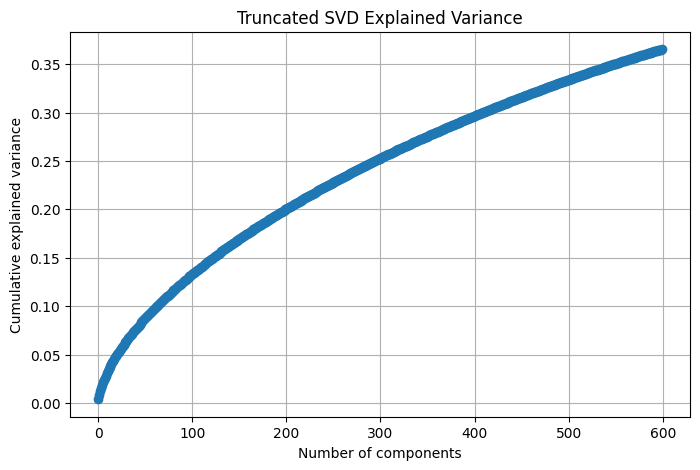

In [ ]:
# SVD Titles
# ----------
svd_posts = TruncatedSVD(n_components=600, random_state=42)
svd_posts.fit(tfidf_full_text)

# Explained Variance Ratio
explained_ratio = svd_posts.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

# Plot Cumulative Variance
plt.figure(figsize=(8,5))
plt.plot(cumulative_ratio, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Truncated SVD Explained Variance")
plt.grid(True)
plt.show()

# SVD Comments
# ------------
# svd_comments = TruncatedSVD(n_components=600, random_state=42)
# svd_comments.fit(tfidf_comments)

##### Truncated SVD

In [ ]:
# SVD Posts
# ---------
svd_posts = TruncatedSVD(n_components=25, random_state=42)
tfidf_titles_reduced = svd_posts.fit_transform(tfidf_titles)
tfidf_contents_reduced = svd_posts.fit_transform(tfidf_contents)
tfidf_full_text_reduced = svd_posts.fit_transform(tfidf_full_text)

# SVD Comments
# ------------
# svd_comments = TruncatedSVD(n_components=50, random_state=42)
# tfidf_comments_reduced = svd_comments.fit_transform(tfidf_comments)

#### Clustering

##### Silhouette Score

TF-IDF vectors are inherently sparse and directional, with each vector representing a document in a high-dimensional space. L2 normalization places all vectors on the unit hypersphere, emphasizing their direction rather than magnitude. Cosine distance, which measures the angle between vectors rather than their length, is therefore more appropriate for comparing documents: two documents with similar word distributions but different lengths will have a small cosine distance. In contrast, Euclidean distance can be misleading, as it is sensitive to magnitude differences rather than actual content similarity. As a result, using the silhouette score with cosine distance provides a more meaningful evaluation of clustering quality for text, better reflecting the semantic similarity between documents and the cohesion and separation of clusters.

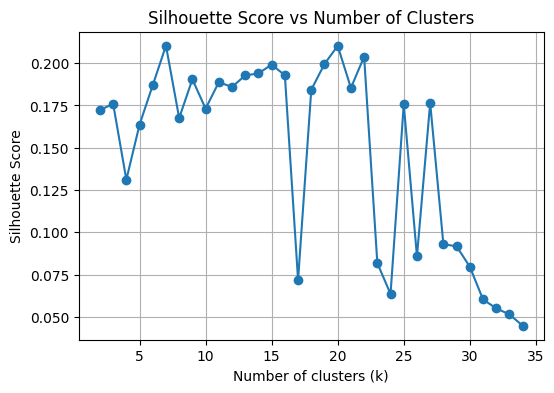

In [ ]:
sil_scores = []
k_values = range(2, 35)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(tfidf_full_text_reduced)

    # Silhouette Score
    # ----------------
    # Use cosine metric because TF-IDF vectors are directional
    score = silhouette_score(tfidf_full_text_reduced, labels, metric='cosine')
    sil_scores.append(score)

# ----
# Plot
# ----
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

##### K-Means Clustering

In [ ]:
df_posts = df_posts.reset_index(drop=True)
posts_cluster_labels = get_kmeans_labels(
    tfidf_full_text_reduced,
    n_clusters=20,
    random_state=42
)

# ------------
# Write Labels
# ------------
print("Saving Labels to PostVault...")

assert len(df_posts) == len(posts_cluster_labels), \
    f"Size mismatch: df_posts={len(df_posts)}, labels={len(posts_cluster_labels)}"

df_posts['tfidf_cluster'] = posts_cluster_labels

save_single_df_to_csv(df_posts, "/content/drive/MyDrive/CS5246Project/data/", "PostVault")

-----------------------------------
K-Means Clustering (k=20) Completed
-----------------------------------
Shape of cluster labels: (31957,)
First 10 labels: [13  8 13 10  9  9 13  8 13 15]
Saving Labels to PostVault...
Saving DataFrames to '/content/drive/MyDrive/CS5246Project/data/' with name 'PostVault'...
----------------------------------------------------------------------------------------------------
PostVault saved to /content/drive/MyDrive/CS5246Project/data/PostVault.csv
----------------------------------------------------------------------------------------------------


#### Visualization

##### Stratified Sampling

We use stratified sampling because our dataset contains 31,923 entries, which would make running t-SNE computationally intensive. Stratified sampling allows us to reduce the dataset size while preserving the original class distribution.

In [ ]:
sampled_tfidf_full_text_reduced, _, sampled_posts_cluster_labels, _ = train_test_split(
    tfidf_full_text_reduced,
    posts_cluster_labels,
    test_size=0.9,                  # 10% for t-SNE
    stratify=posts_cluster_labels,  # stratified sampling
    random_state=42
)

print("--------------------------------")
print("Sampled Data Shape:", sampled_tfidf_full_text_reduced.shape)
print("--------------------------------")

--------------------------------
Sampled Data Shape: (3195, 25)
--------------------------------


##### t-SNE

In [ ]:
# Full Data
# ---------
# posts_tsne_3d = perform_tsne(tfidf_posts_reduced)

# Sampled Data
# ------------
sampled_contents_tsne_3d = perform_tsne(sampled_tfidf_full_text_reduced, n_components=3)

print("-----------------------------------------------------")
print("t-SNE 3D Dimensionality Reduction for Posts Completed")
print("-----------------------------------------------------")
print("Shape of posts_tsne_2d:", sampled_contents_tsne_3d.shape)
print("First 5 rows of posts_tsne_2d:\n", sampled_contents_tsne_3d[:5])

--------------------------------------------
t-SNE 3D Dimensionality Reduction Completed
--------------------------------------------
Shape of tsne_results: (3195, 3)
First 5 rows of tsne_results:
[[ -6.1729627   -4.6388407  -14.556463  ]
 [ -6.32122      0.7318911    5.0324864 ]
 [-11.490724     2.5593398    2.4966424 ]
 [ -5.157028    -5.0016384   14.023712  ]
 [ 22.441206     2.5392885    0.65534896]]
-----------------------------------------------------
t-SNE 3D Dimensionality Reduction for Posts Completed
-----------------------------------------------------
Shape of posts_tsne_2d: (3195, 3)
First 5 rows of posts_tsne_2d:
 [[ -6.1729627   -4.6388407  -14.556463  ]
 [ -6.32122      0.7318911    5.0324864 ]
 [-11.490724     2.5593398    2.4966424 ]
 [ -5.157028    -5.0016384   14.023712  ]
 [ 22.441206     2.5392885    0.65534896]]


##### Scatter Plot Visualization

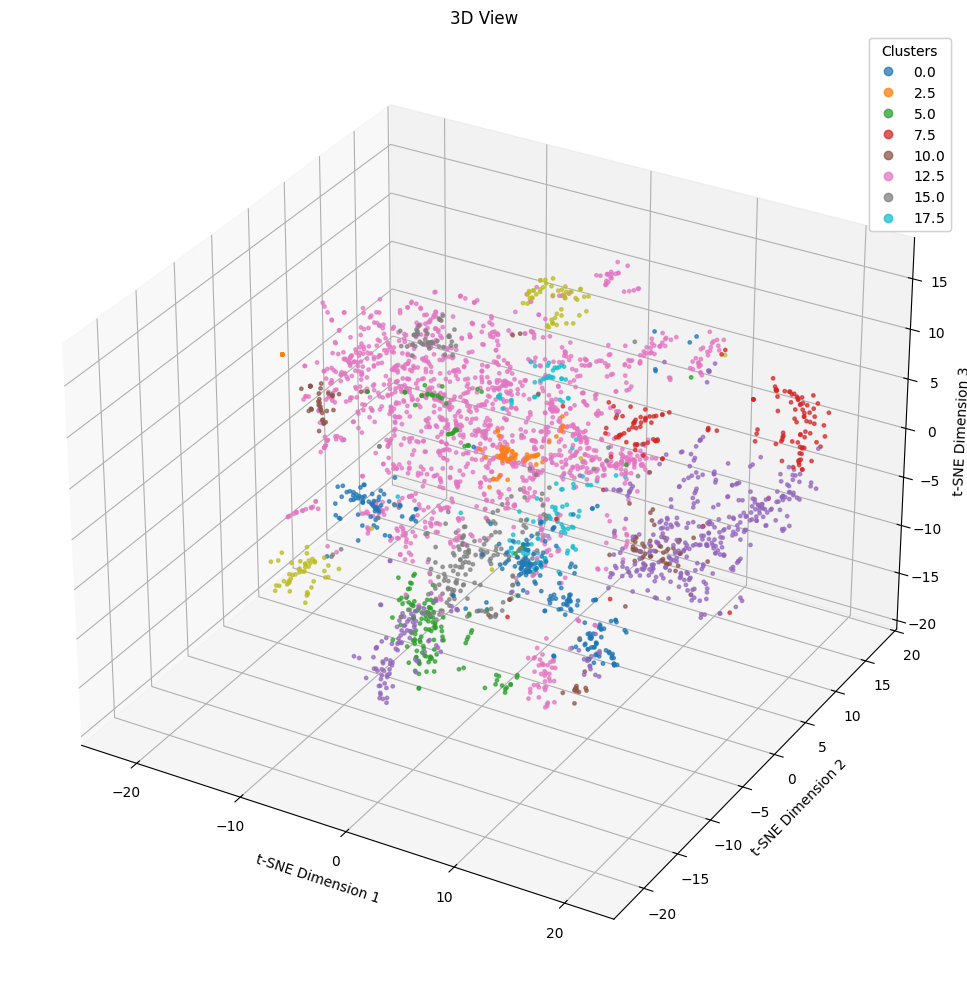

In [ ]:
# ---------
# Full Data
# ---------
# plot_scatter(posts_tsne_3d, posts_cluster_labels, title="3D View")

# ------------
# Sampled Data
# ------------
plot_scatter(sampled_contents_tsne_3d, sampled_posts_cluster_labels, title="3D View")

#### Data Analysis

##### Word Cloud

Visualizing Cluster 0


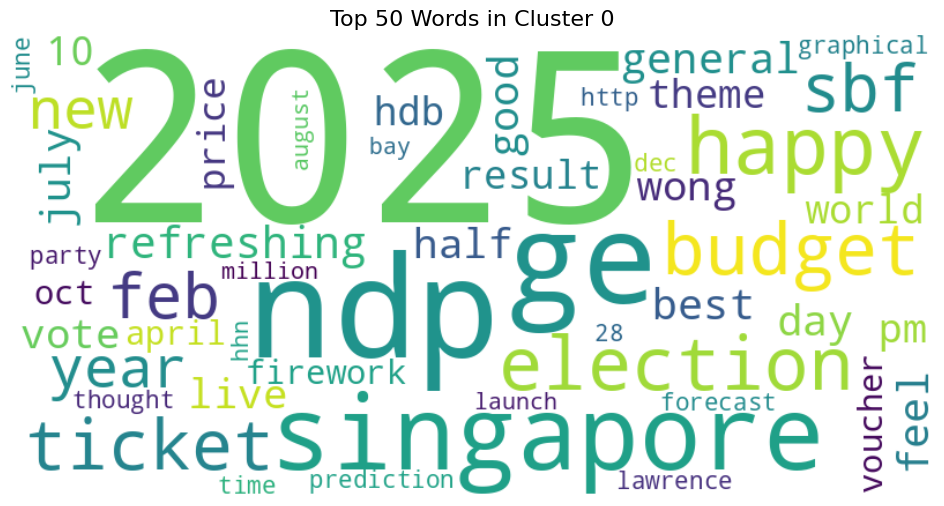

Visualizing Cluster 1


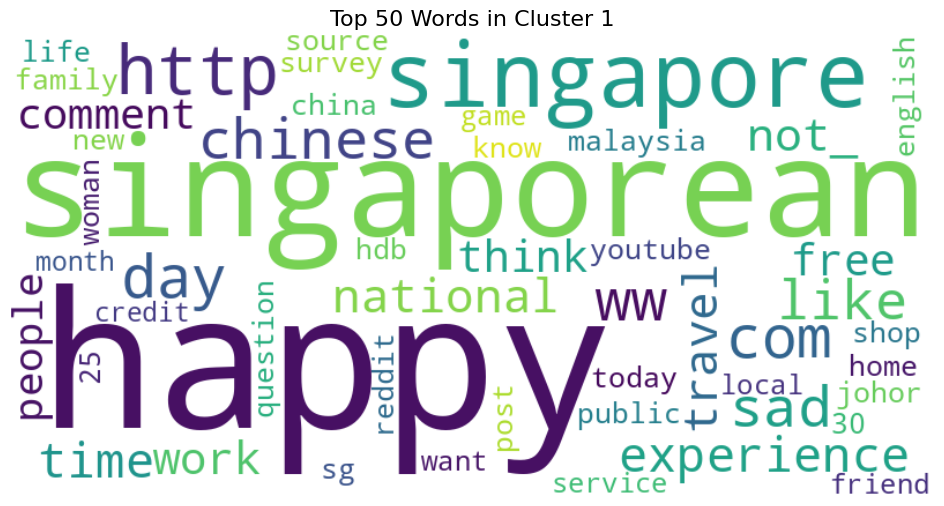

Visualizing Cluster 2


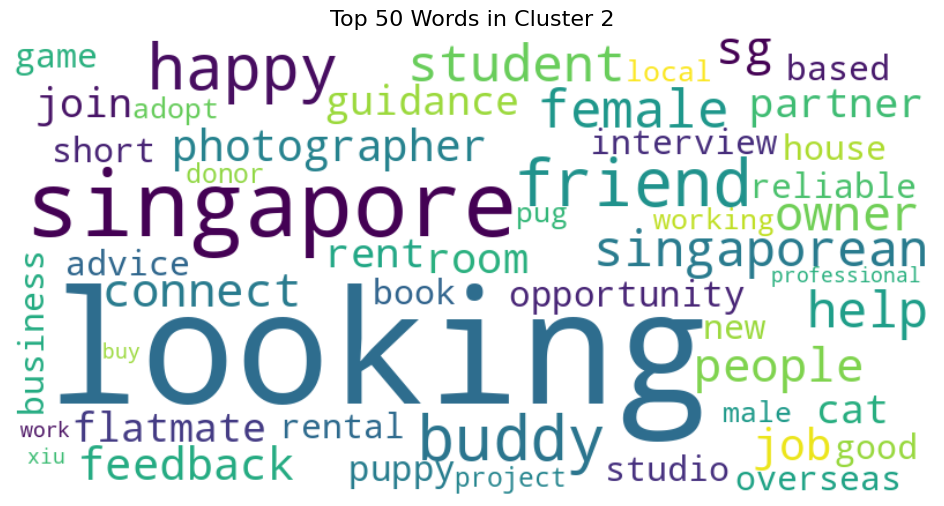

Visualizing Cluster 3


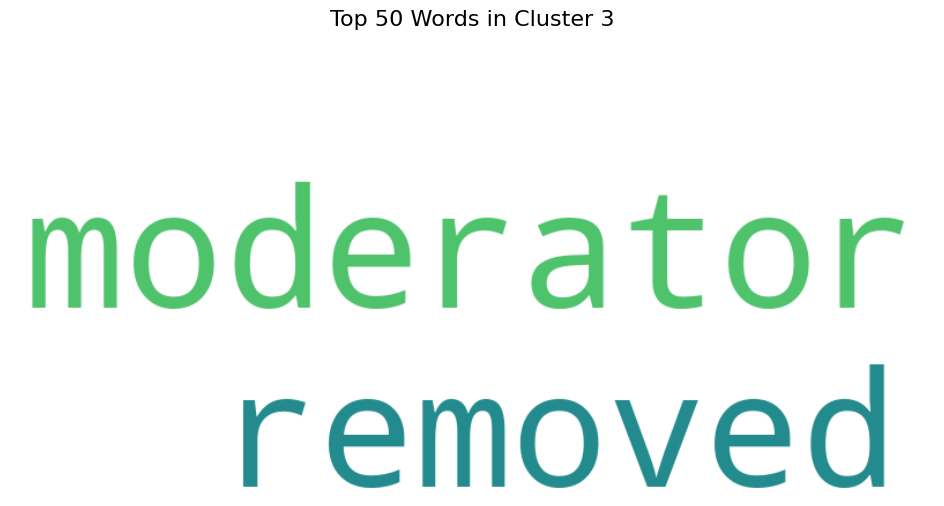

Visualizing Cluster 4


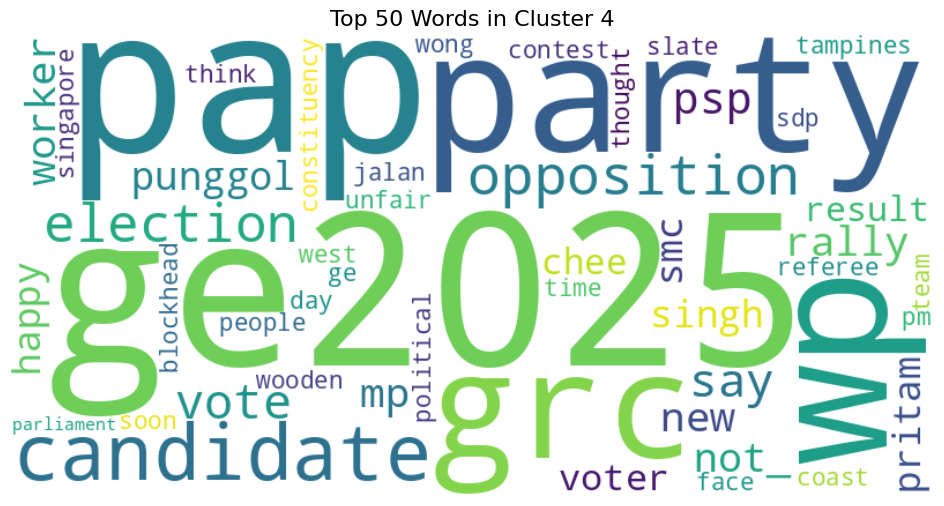

Visualizing Cluster 5


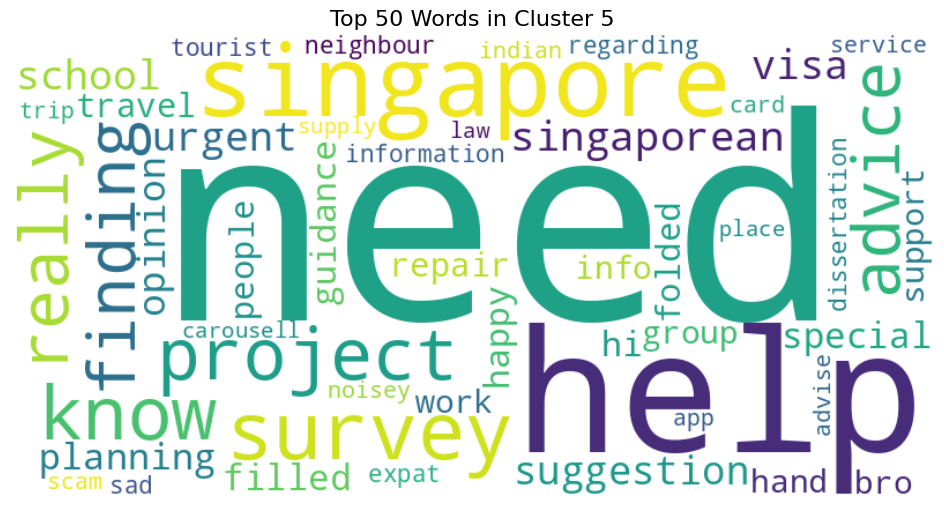

Visualizing Cluster 6


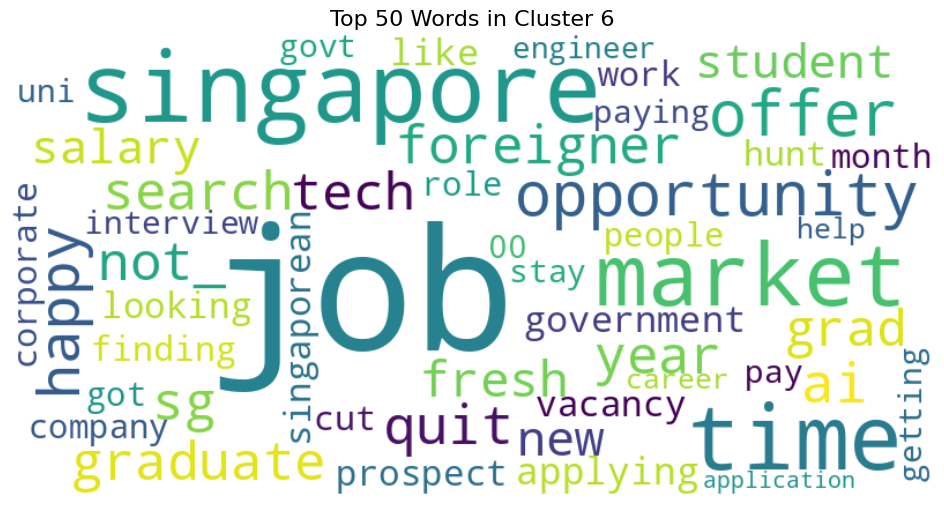

Visualizing Cluster 7


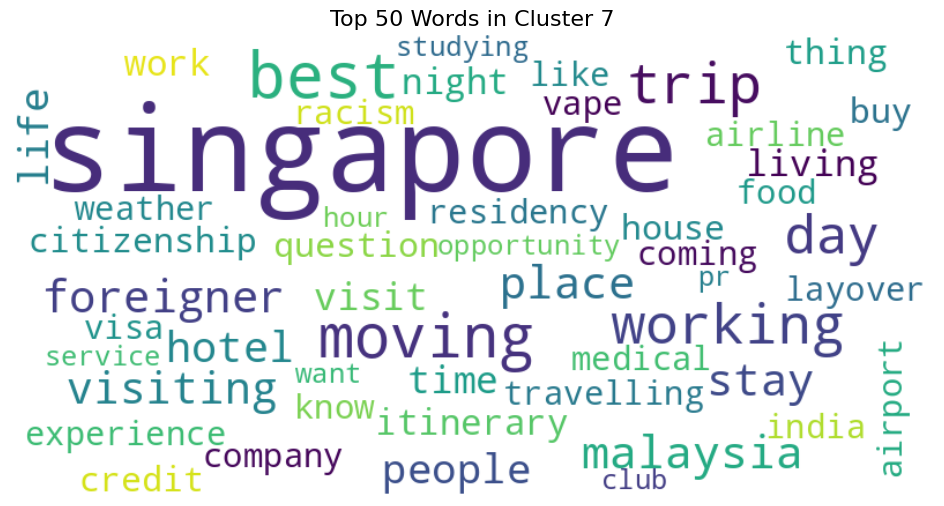

Visualizing Cluster 8


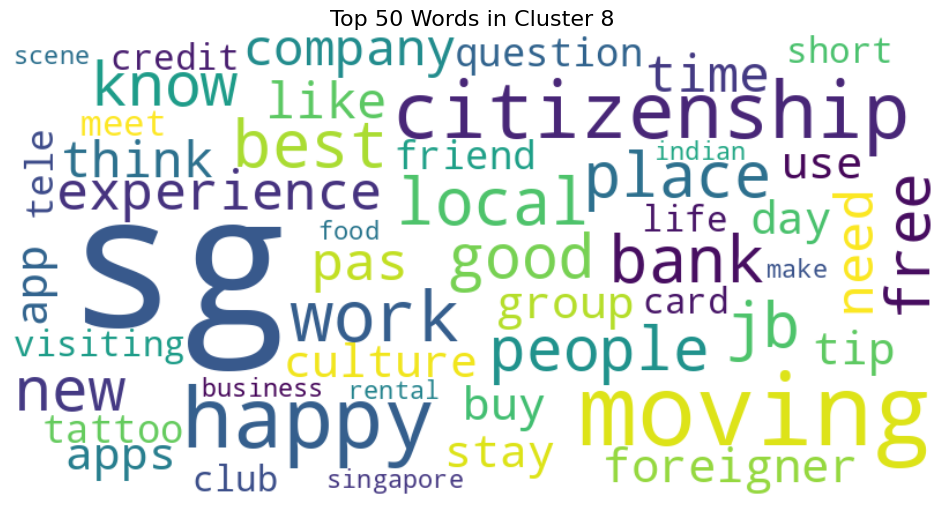

Visualizing Cluster 9


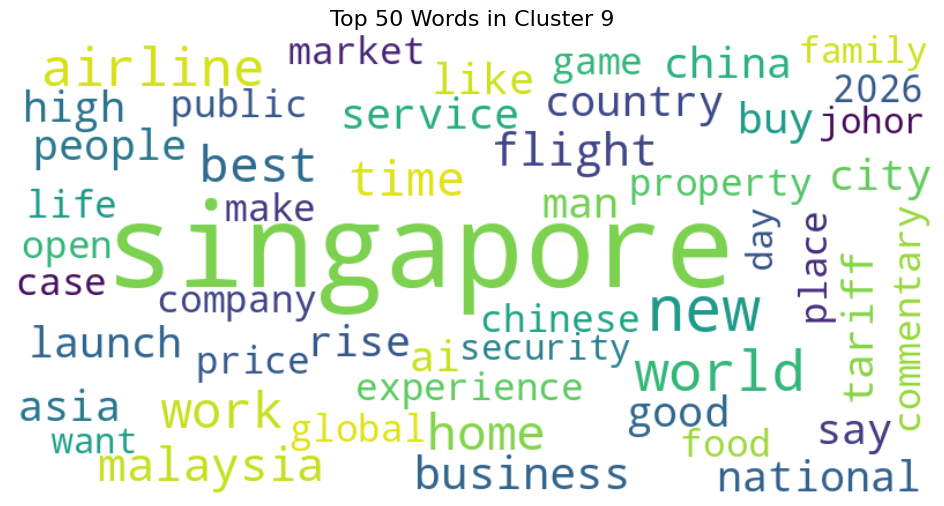

Visualizing Cluster 10


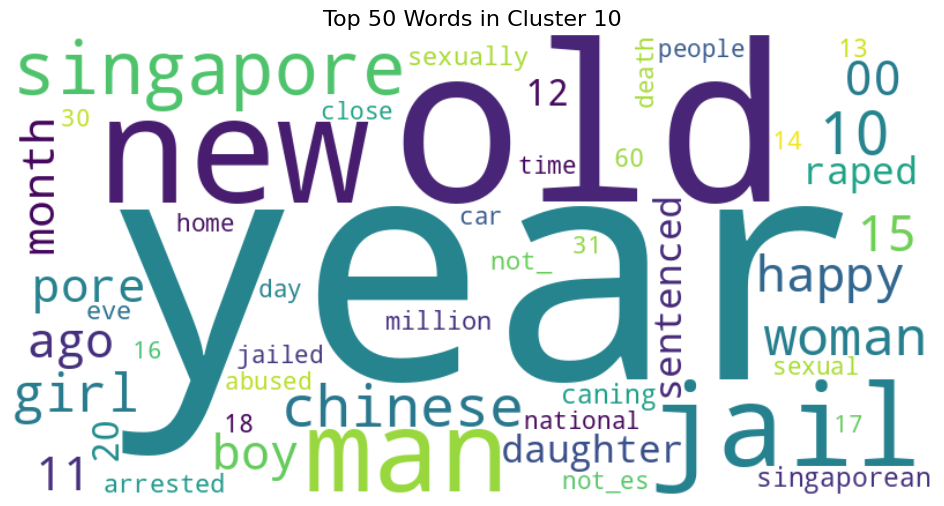

Visualizing Cluster 11


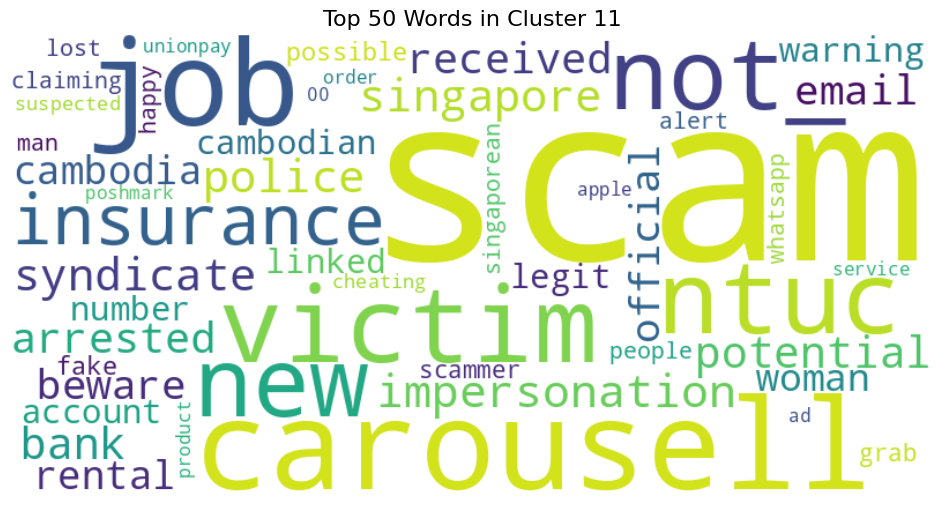

Visualizing Cluster 12


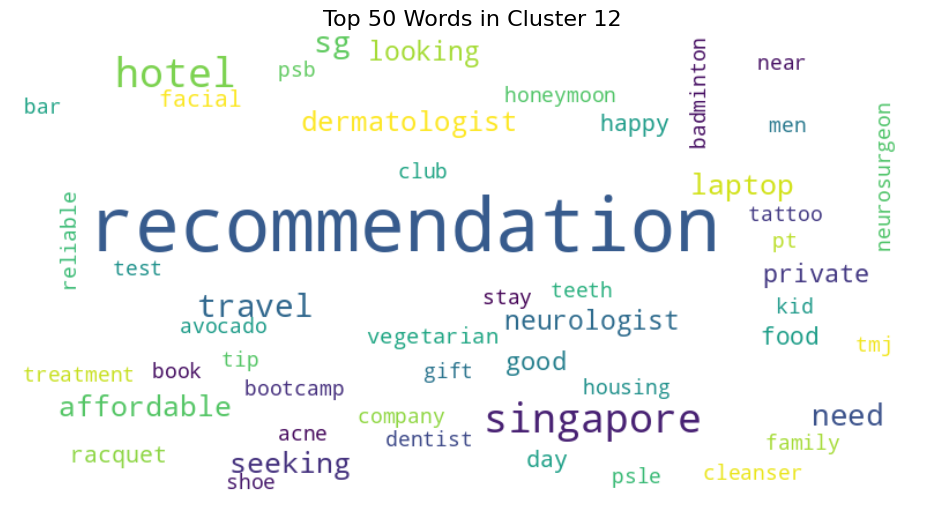

Visualizing Cluster 13


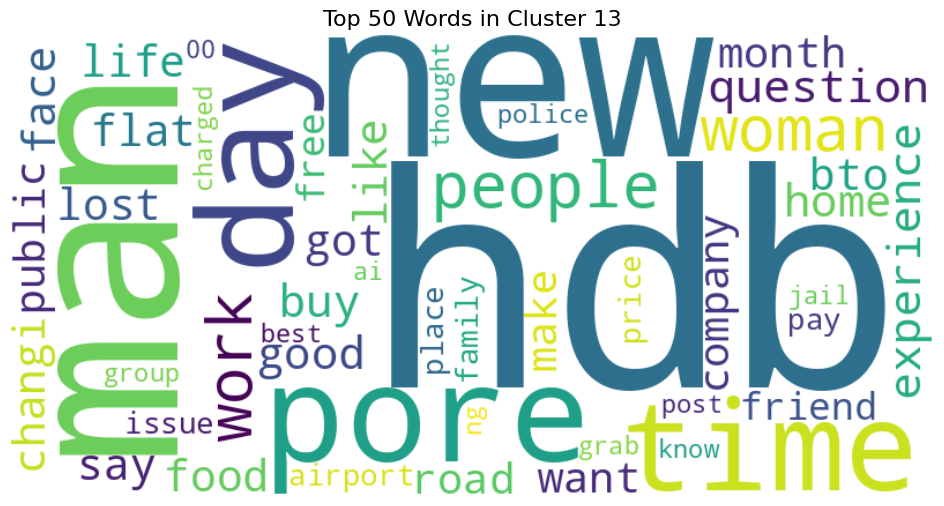

Visualizing Cluster 14


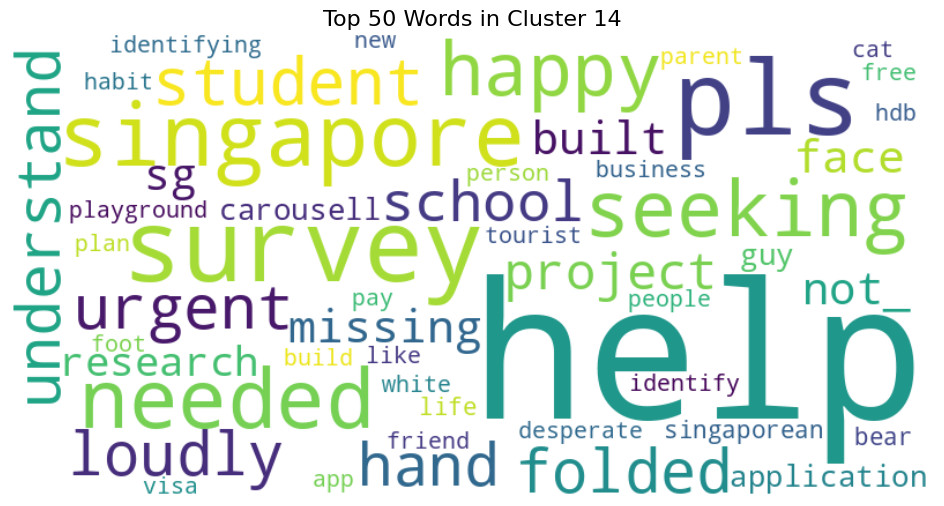

Visualizing Cluster 15


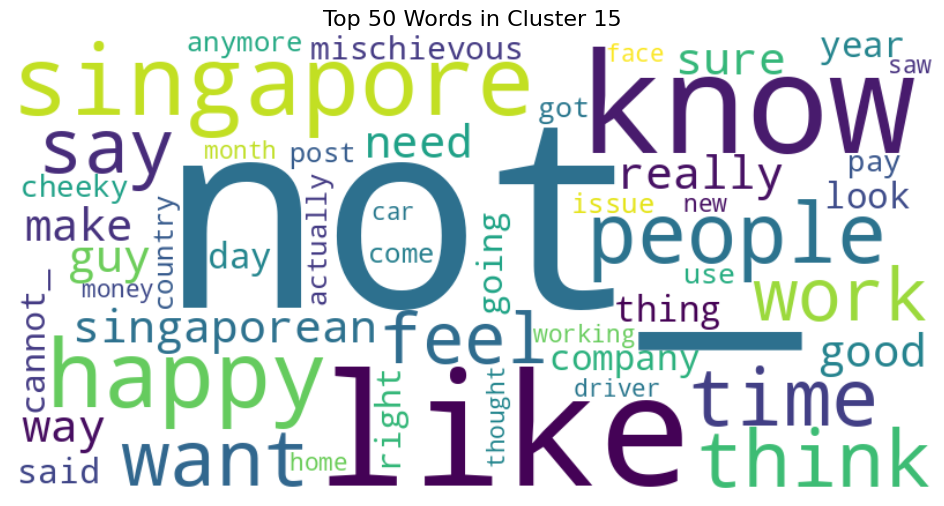

Visualizing Cluster 16


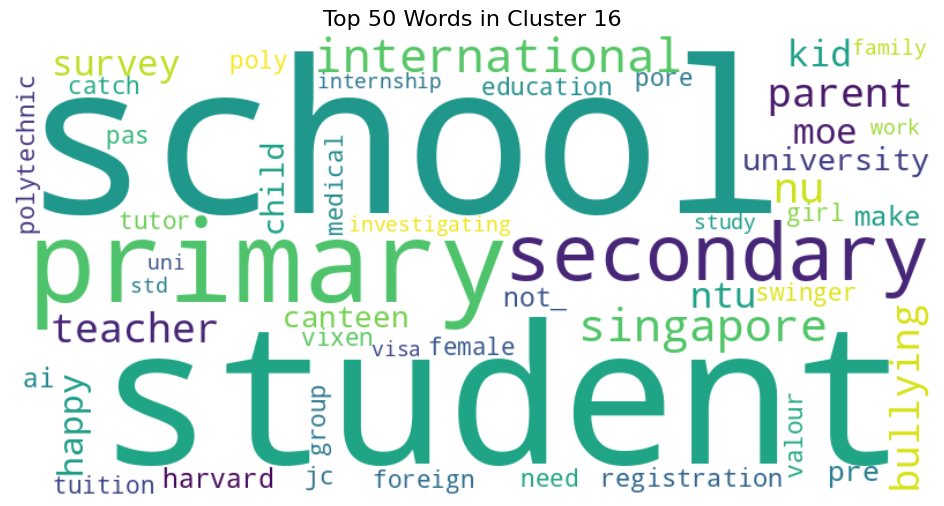

Visualizing Cluster 17


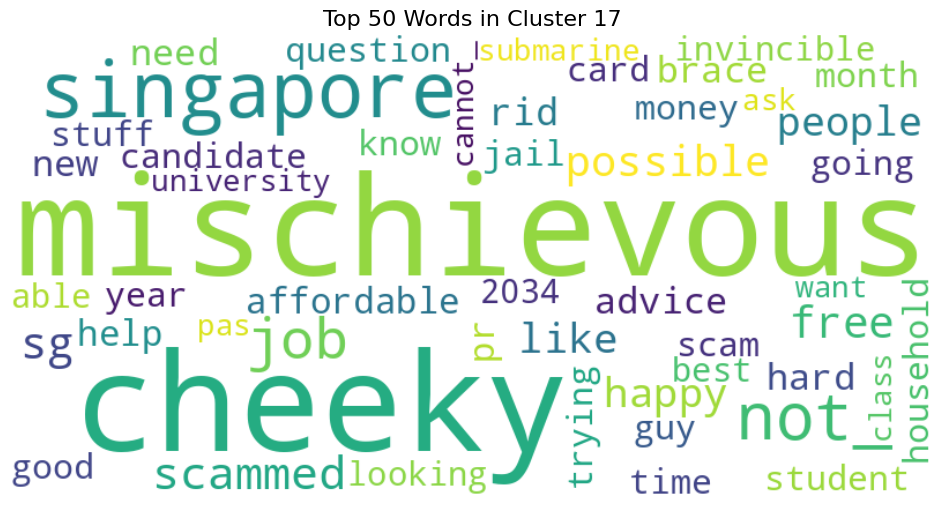

Visualizing Cluster 18


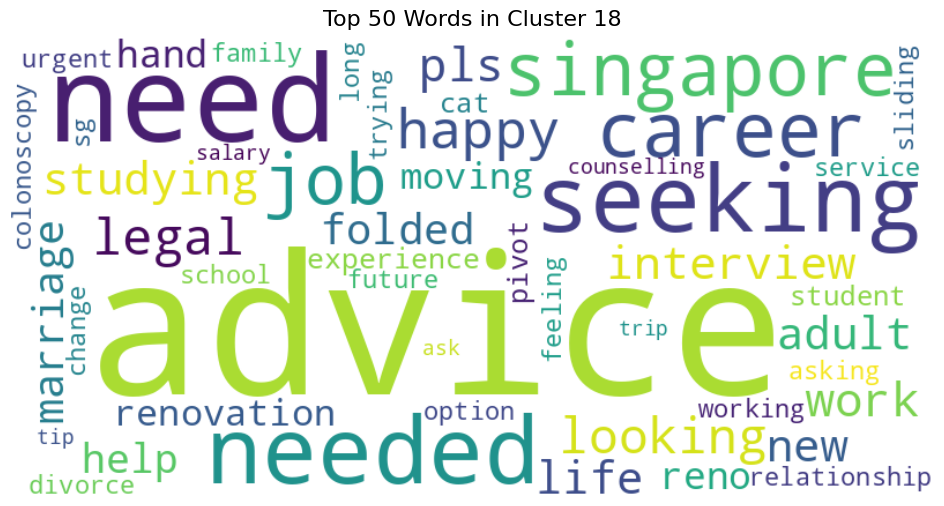

Visualizing Cluster 19


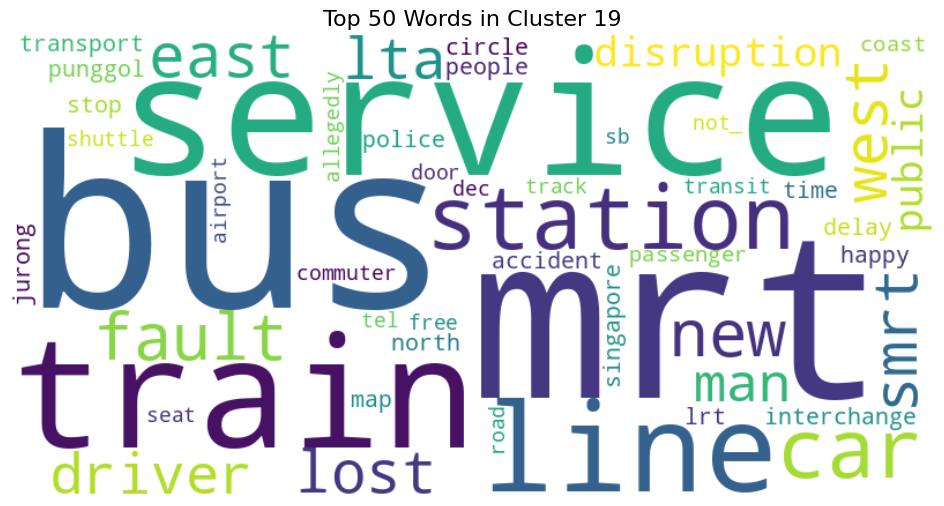

In [ ]:
generate_cluster_wordclouds(tfidf_full_text, tfidf_posts_vectorizer, labels=None, df=df_posts, cluster_col='tfidf_cluster', top_n=50)

##### Keyword Extraction

In [ ]:
keywords_dict = get_cluster_keywords(tfidf_full_text, tfidf_posts_vectorizer, labels=None, df=df_posts, cluster_col='tfidf_cluster', n_top_words=10)

Extracting top 10 keywords per cluster...
----------------------------------------
Cluster 0:
  Keywords: 2025, ndp, ge, singapore, happy, election, budget, ticket, sbf, feb
----------------------------------------
Cluster 1:
  Keywords: happy, singaporean, singapore, http, day, com, ww, sad, chinese, like
----------------------------------------
Cluster 2:
  Keywords: looking, singapore, friend, happy, buddy, female, student, help, singaporean, owner
----------------------------------------
Cluster 3:
  Keywords: moderator, removed, emergence, emergency, emerges, emerging, emeritus, emilianou, emily, emirate
----------------------------------------
Cluster 4:
  Keywords: ge2025, pap, party, wp, grc, candidate, opposition, election, vote, say
----------------------------------------
Cluster 5:
  Keywords: need, help, singapore, survey, know, project, really, advice, finding, singaporean
----------------------------------------
Cluster 6:
  Keywords: job, singapore, time, market, offer,

### BM25

#### Load Data

In [ ]:
# ------------------
# Load BM25 Matrices
# ------------------
bm25_titles = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/bm25_titles.npz')
bm25_contents = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/bm25_contents.npz')
bm25_full_text = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/bm25_fulltext.npz')

bm25_comments = load_npz('/content/drive/MyDrive/CS5246Project/data/vector_database/bm25_comments.npz')

# -------------------------------
# Load PostVault and CommentVault
# -------------------------------
df_posts = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/PostVault.csv', keep_default_na=False)
df_comments = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/CommentVault.csv', keep_default_na=False)

# ---------------
# Load BM25 Model
# ---------------
bm25_titles_model = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/bm25_titles_model.joblib')
bm25_fulltext_model = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/bm25_fulltext_model.joblib')
bm25_comments_model = joblib.load('/content/drive/MyDrive/CS5246Project/data/models/bm25_comments_model.joblib')

print("-----------------------------------------------")
print("BM25 for posts and comments loaded successfully")
print("-----------------------------------------------")

-----------------------------------------------
BM25 for posts and comments loaded successfully
-----------------------------------------------


#### Dimensionality Reduction

To reduce the original high-dimensional space, we apply Truncated SVD. This technique is well-suited for sparse representations such as TF-IDF, as it captures the main directions of variation (latent components) and projects the data into a lower-dimensional dense space. In NLP, this approach is also known as Latent Semantic Analysis (LSA).

The goal is to retain most of the meaningful structure in the data while dramatically reducing dimensionality. This step is important because t-SNE does not operate efficiently on sparse matrices, and directly converting TF-IDF into a dense representation would be computationally and memory intensive. Truncated SVD makes the process feasible by compressing the feature space (for example, from ~100,000 dimensions down to 50–100), enabling t-SNE to run effectively and efficiently.

##### Explained Variance Ratio

We check the explained variance ratio first because it helps us understand how much information each SVD component retains. BM25 matrices are very high-dimensional and sparse, so not all components contribute equally. By examining the cumulative explained variance, we can choose a reasonable number of components that capture most of the important variance while keeping the data small enough for efficient t-SNE computation. This ensures that our t-SNE visualization preserves meaningful structure without unnecessary computation or memory usage.

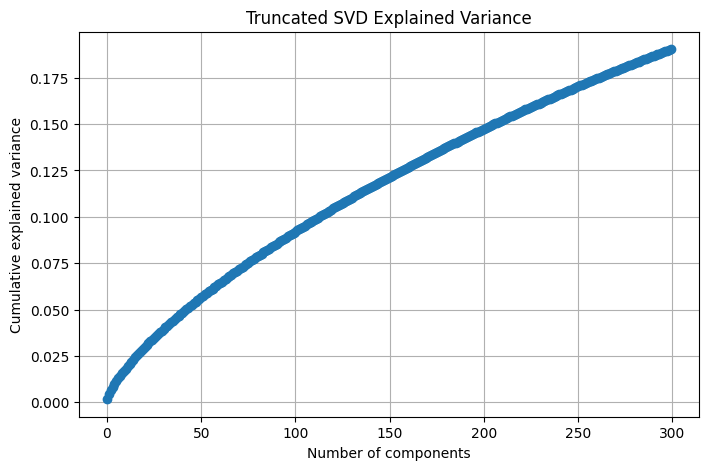

In [ ]:
# SVD Posts
# ---------
svd_posts = TruncatedSVD(n_components=300, random_state=42)
svd_posts.fit(bm25_full_text)

# Explained Variance Ratio
explained_ratio = svd_posts.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

# Plot Cumulative Variance
plt.figure(figsize=(8,5))
plt.plot(cumulative_ratio, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Truncated SVD Explained Variance")
plt.grid(True)
plt.show()

# SVD Comments
# ------------
# svd_comments = TruncatedSVD(n_components=600, random_state=42)
# svd_comments.fit(bm25_comments)

##### Truncated SVD

In [ ]:
# SVD Posts
# ---------
svd_posts = TruncatedSVD(n_components=150, random_state=42)

bm25_titles_reduced = svd_posts.fit_transform(bm25_titles)
bm25_contents_reduced = svd_posts.fit_transform(bm25_contents)
bm25_full_text_reduced = svd_posts.fit_transform(bm25_full_text)

# SVD Comments
# ------------
# svd_comments = TruncatedSVD(n_components=50, random_state=42)
# tfidf_comments_reduced = svd_comments.fit_transform(tfidf_comments)

#### Clustering

##### Silhouette Score

BM25 vectors are inherently sparse and directional, with each vector representing a document in a high-dimensional space. L2 normalization places all vectors on the unit hypersphere, emphasizing their direction rather than magnitude. Cosine distance, which measures the angle between vectors rather than their length, is therefore more appropriate for comparing documents: two documents with similar word distributions but different lengths will have a small cosine distance. In contrast, Euclidean distance can be misleading, as it is sensitive to magnitude differences rather than actual content similarity. As a result, using the silhouette score with cosine distance provides a more meaningful evaluation of clustering quality for text, better reflecting the semantic similarity between documents and the cohesion and separation of clusters.

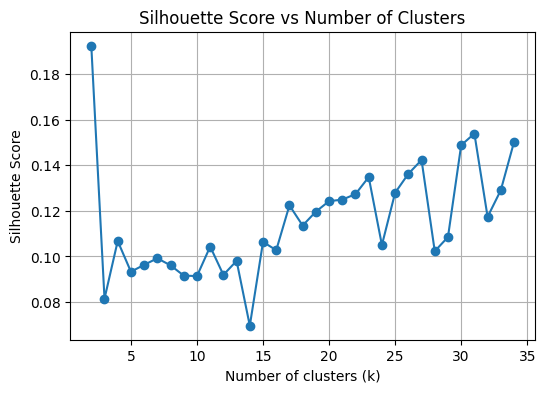

In [ ]:
sil_scores = []
# n_components = 150, n = 33, 0.122
k_values = range(2, 35)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(bm25_full_text_reduced)

    # Silhouette Score
    # ----------------
    # Use cosine metric because BM25 vectors are directional
    score = silhouette_score(bm25_full_text_reduced, labels, metric='cosine')
    sil_scores.append(score)

# ----
# Plot
# ----
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

##### K-Means Clustering

In [ ]:
posts_cluster_labels = get_kmeans_labels(bm25_full_text_reduced, n_clusters=31, random_state=42)

# ------------
# Write Labels
# ------------
print("Saving Labels to PostVault...")

assert len(df_posts) == len(posts_cluster_labels), \
    f"Size mismatch: df_posts={len(df_posts)}, labels={len(posts_cluster_labels)}"

df_posts['bm25_cluster'] = posts_cluster_labels

save_single_df_to_csv(df_posts, "/content/drive/MyDrive/CS5246Project/data/", "PostVault")


-----------------------------------
K-Means Clustering (k=31) Completed
-----------------------------------
Shape of cluster labels: (31957,)
First 10 labels: [23 11 14  3 23 23 20  2 23  3]
Saving Labels to PostVault...
Saving DataFrames to '/content/drive/MyDrive/CS5246Project/data/' with name 'PostVault'...
----------------------------------------------------------------------------------------------------
PostVault saved to /content/drive/MyDrive/CS5246Project/data/PostVault.csv
----------------------------------------------------------------------------------------------------


#### Visualization

##### Stratified Sampling

We use stratified sampling because our dataset contains 31,923 entries, which would make running t-SNE computationally intensive. Stratified sampling allows us to reduce the dataset size while preserving the original class distribution.

In [ ]:
sampled_bm25_full_text_reduced, _, sampled_posts_cluster_labels, _ = train_test_split(
    bm25_full_text_reduced,
    posts_cluster_labels,
    test_size=0.8,                  # 10% for t-SNE
    stratify=posts_cluster_labels,  # stratified sampling
    random_state=42
)

print("-------------------------------")
print("Sampled Data Shape:", sampled_bm25_full_text_reduced.shape)
print("-------------------------------")

-------------------------------
Sampled Data Shape: (6391, 150)
-------------------------------


##### t-SNE

In [ ]:
# ---------
# Full Data
# ---------
# full_text_tsne_3d = perform_tsne(bm25_full_text_reduced)

# ------------
# Sampled Data
# ------------
sampled_full_text_tsne_3d = perform_tsne(sampled_bm25_full_text_reduced)

print("-----------------------------------------------------")
print("t-SNE 3D Dimensionality Reduction for Posts Completed")
print("-----------------------------------------------------")
print("Shape of posts_tsne_3d:", sampled_full_text_tsne_3d.shape)
print("First 5 rows of posts_tsne_3d:\n", sampled_full_text_tsne_3d[:5])

--------------------------------------------
t-SNE 3D Dimensionality Reduction Completed
--------------------------------------------
Shape of tsne_results: (6391, 3)
First 5 rows of tsne_results:
[[ 14.100831   12.849875   20.14397  ]
 [-12.278382    1.8751129  26.08448  ]
 [ 14.286226   -3.865726  -17.815783 ]
 [-16.96814    11.743755   22.837948 ]
 [ -1.8548682  -4.1408362  20.02785  ]]
-----------------------------------------------------
t-SNE 3D Dimensionality Reduction for Posts Completed
-----------------------------------------------------
Shape of posts_tsne_3d: (6391, 3)
First 5 rows of posts_tsne_3d:
 [[ 14.100831   12.849875   20.14397  ]
 [-12.278382    1.8751129  26.08448  ]
 [ 14.286226   -3.865726  -17.815783 ]
 [-16.96814    11.743755   22.837948 ]
 [ -1.8548682  -4.1408362  20.02785  ]]


##### Scatter Plot Visualization

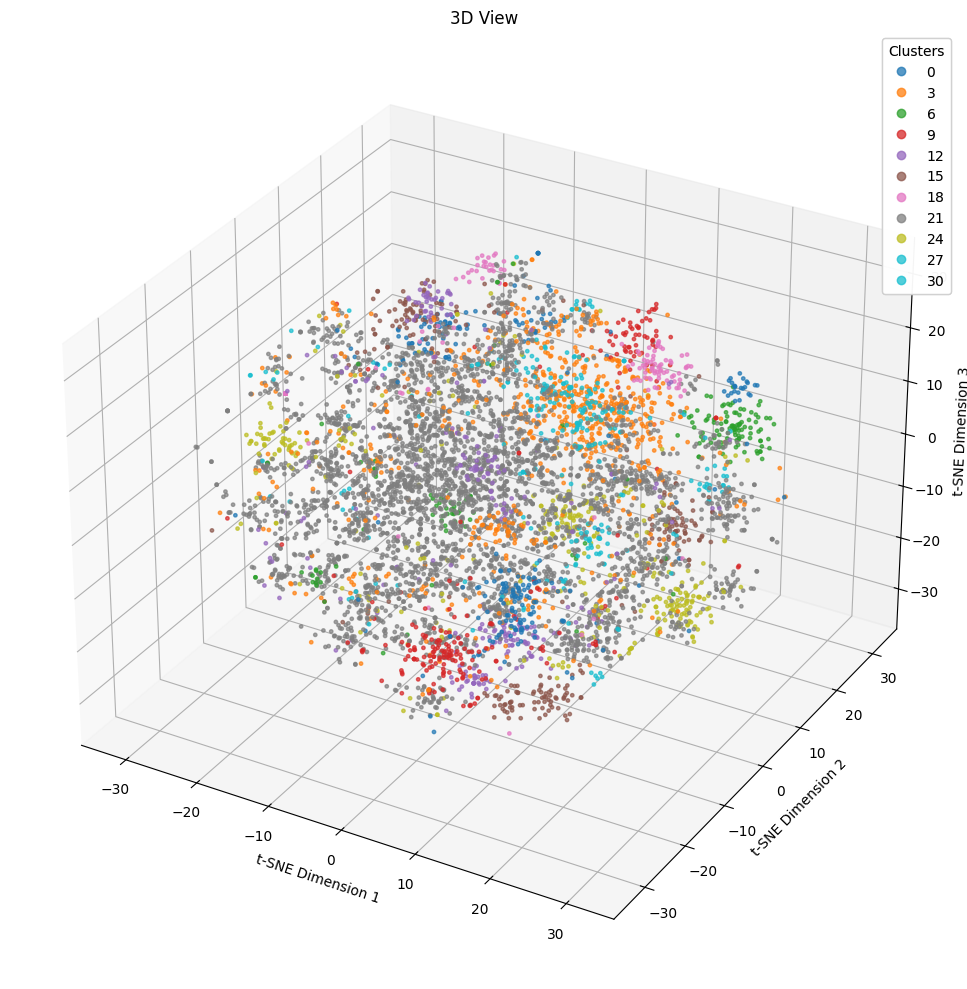

In [ ]:
# ---------
# Full Data
# ---------
# plot_scatter(full_text_tsne_3d, posts_cluster_labels, title="3D View")

# ------------
# Sampled Data
# ------------
plot_scatter(sampled_full_text_tsne_3d, sampled_posts_cluster_labels, title="3D View")

#### Data Analysis

##### Word Cloud

Visualizing Cluster 0


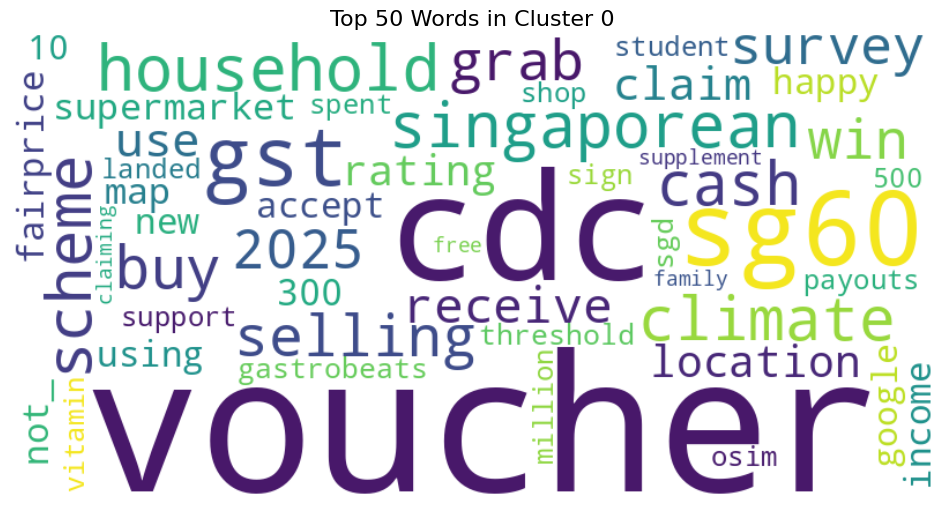

Visualizing Cluster 1


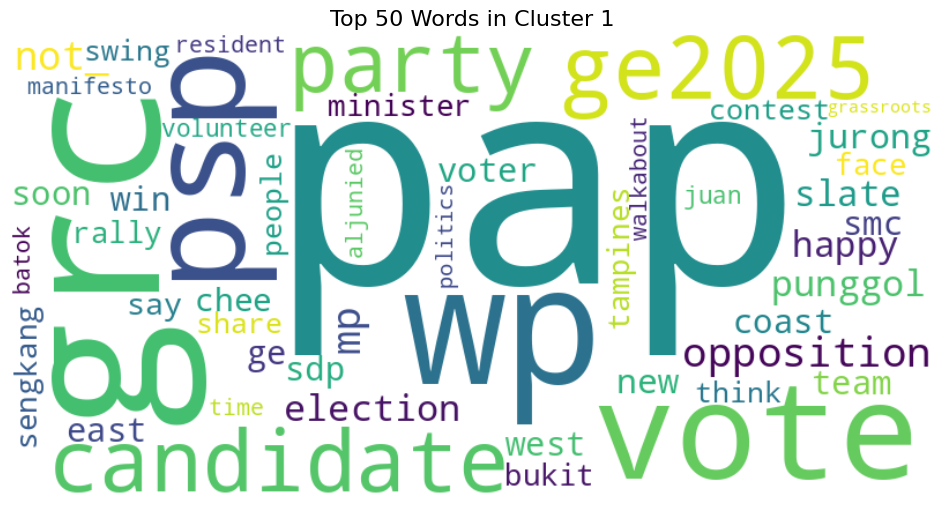

Visualizing Cluster 2


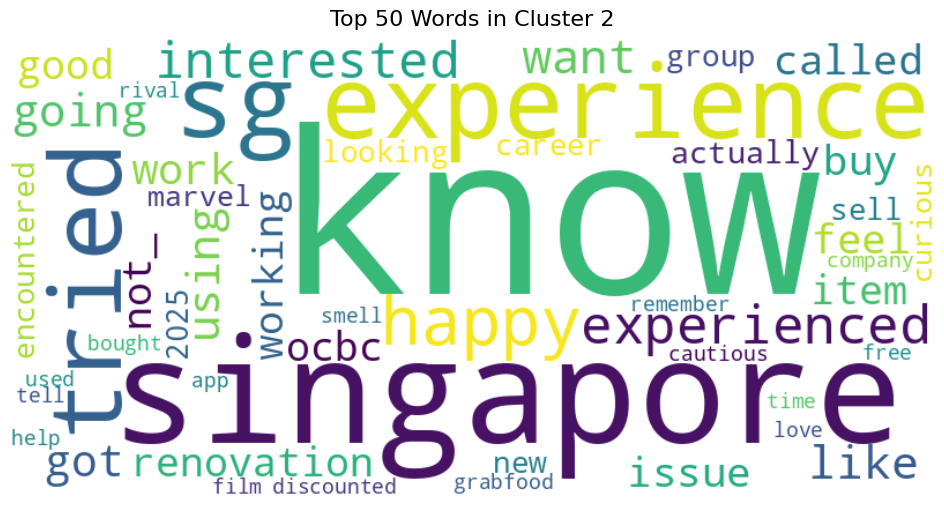

Visualizing Cluster 3


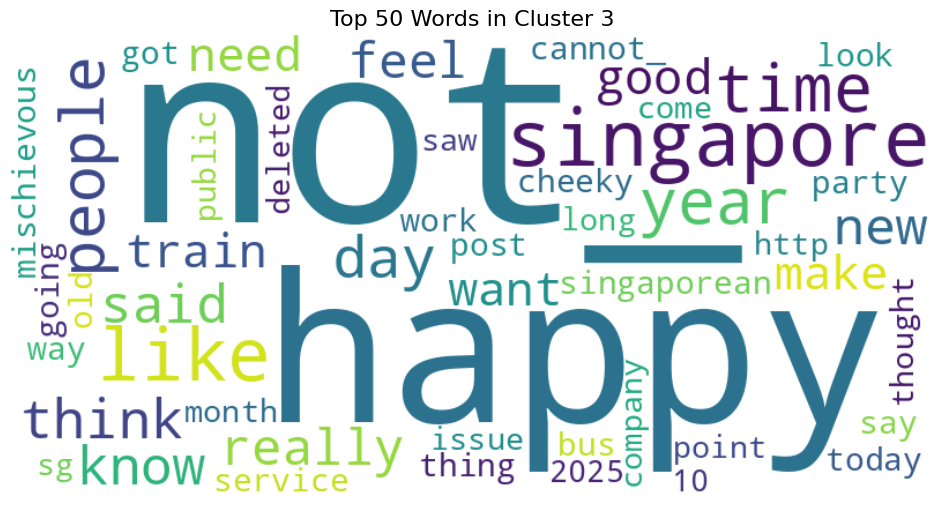

Visualizing Cluster 4


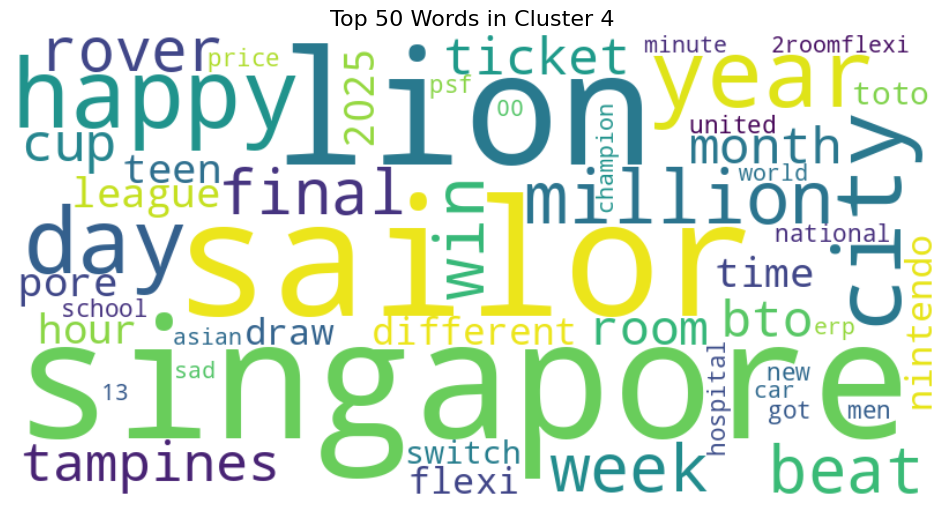

Visualizing Cluster 5


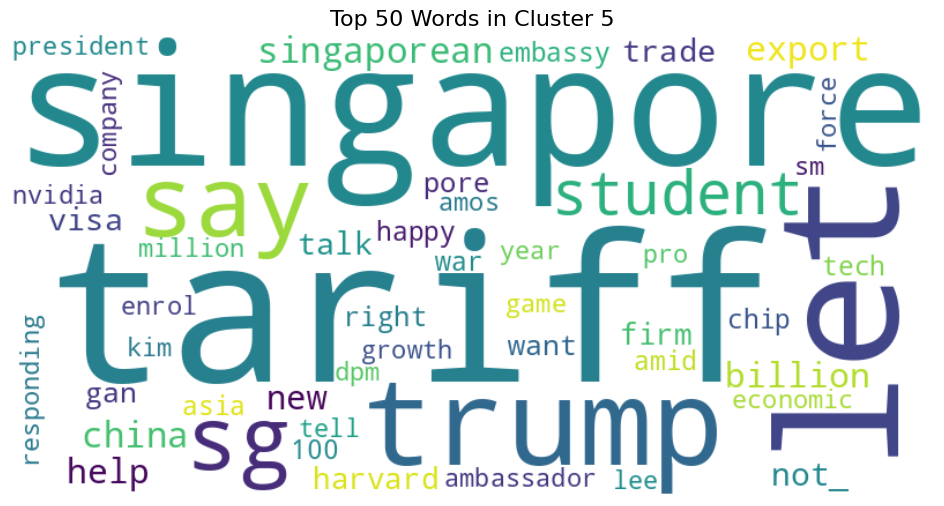

Visualizing Cluster 6


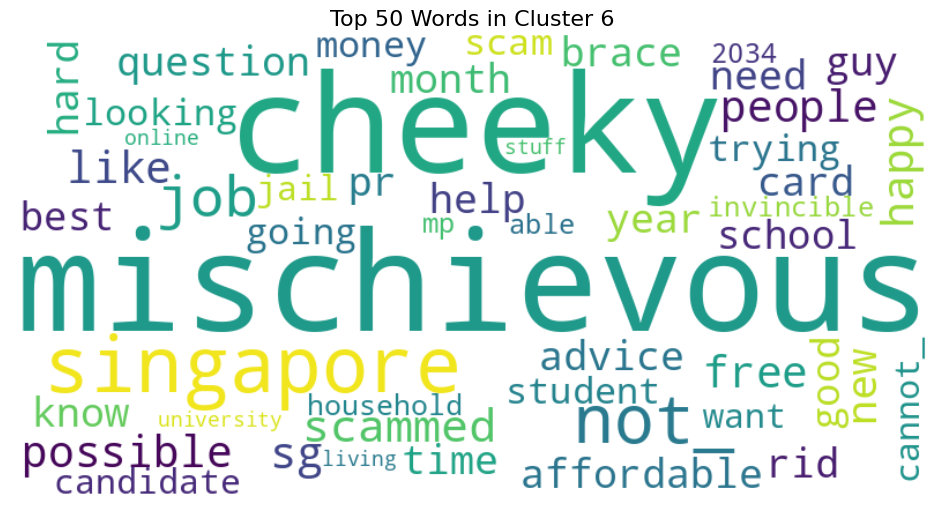

Visualizing Cluster 7


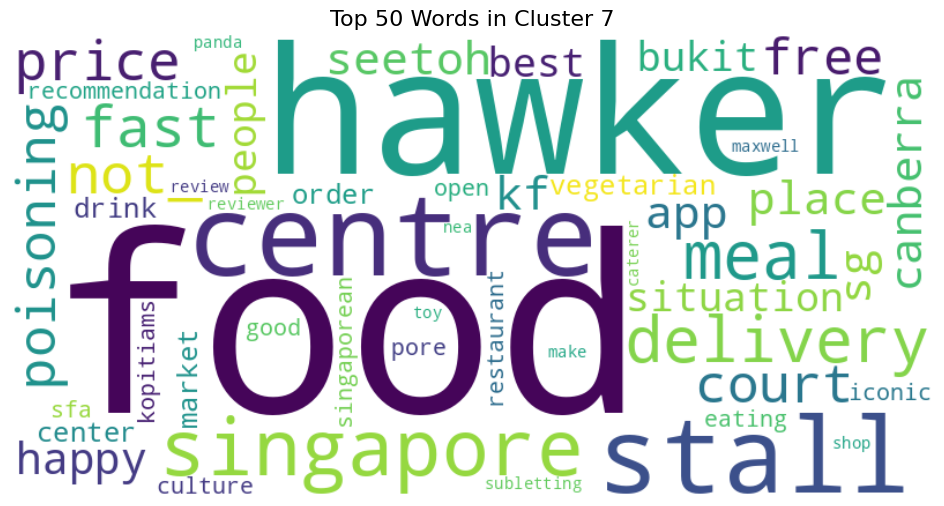

Visualizing Cluster 8


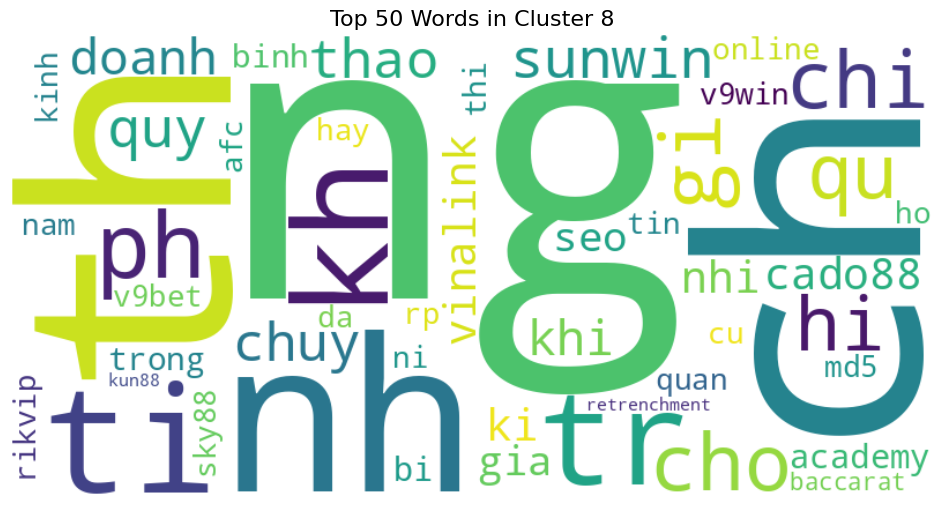

Visualizing Cluster 9


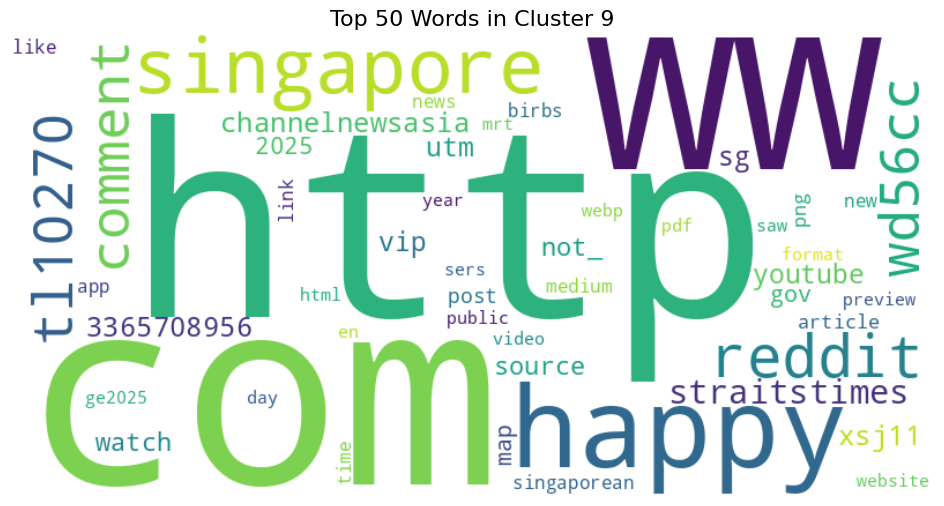

Visualizing Cluster 10


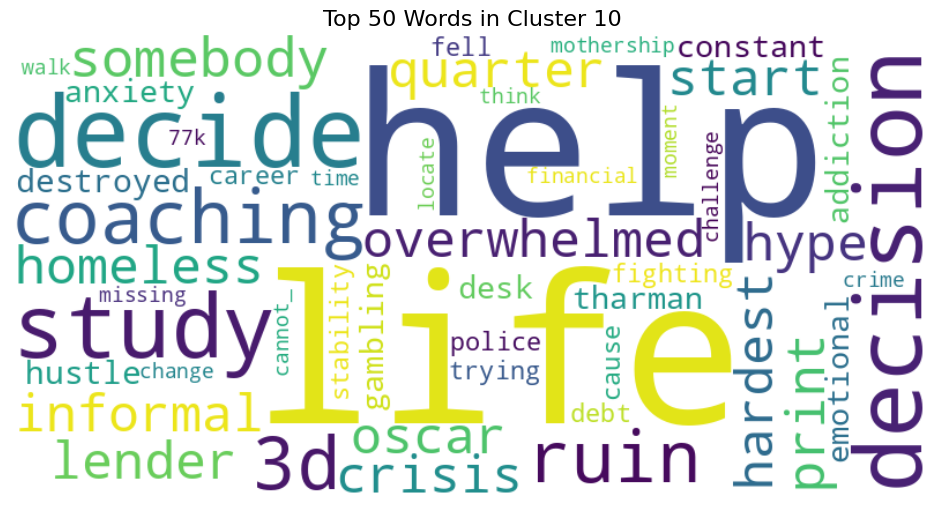

Visualizing Cluster 11


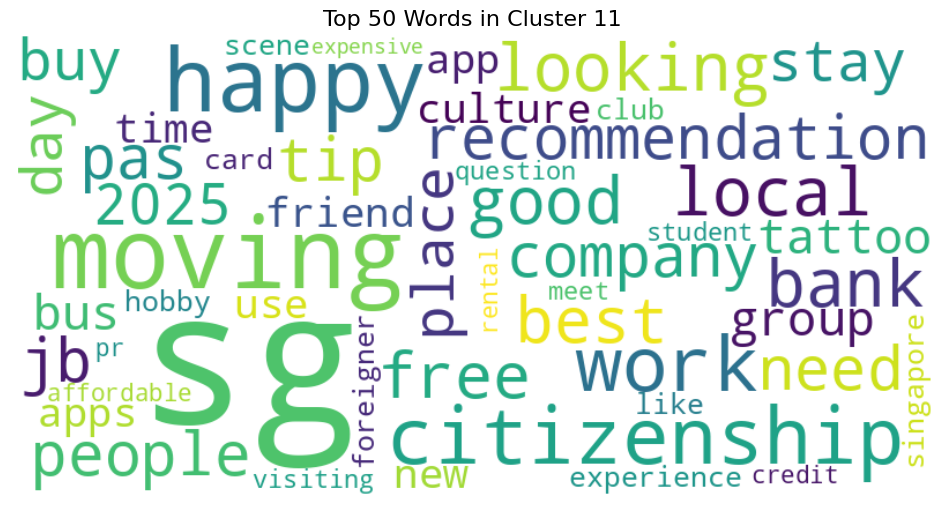

Visualizing Cluster 12


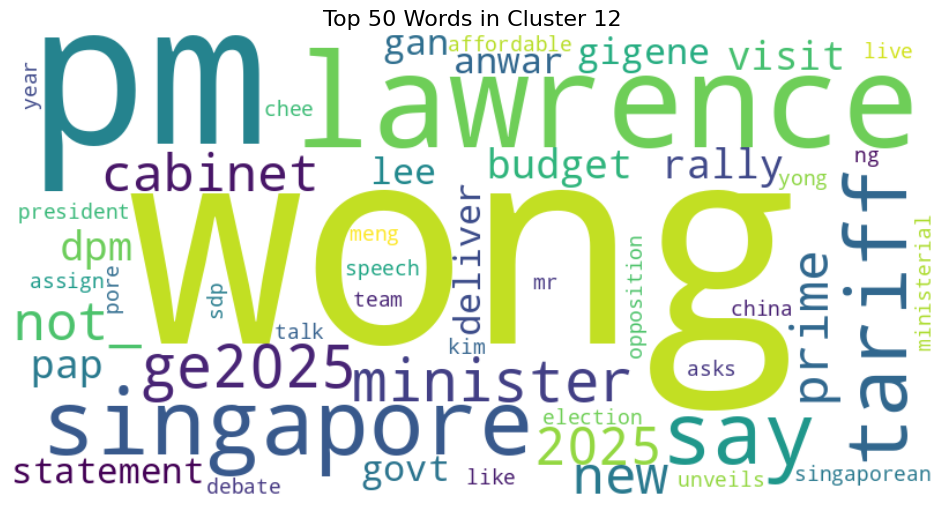

Visualizing Cluster 13


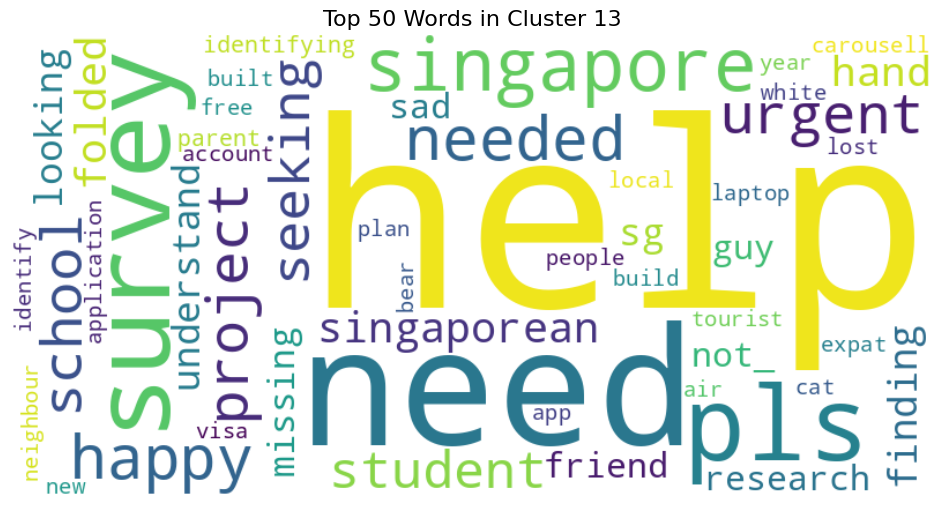

Visualizing Cluster 14


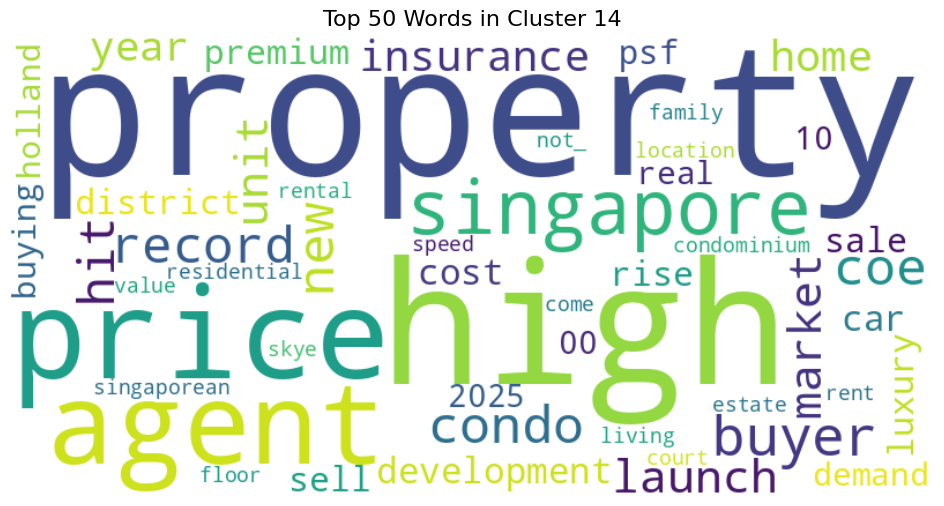

Visualizing Cluster 15


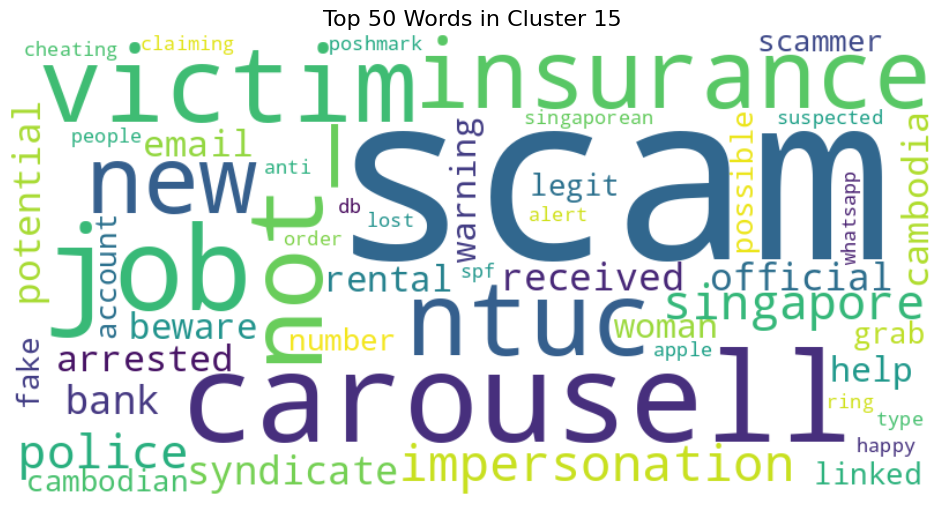

Visualizing Cluster 16


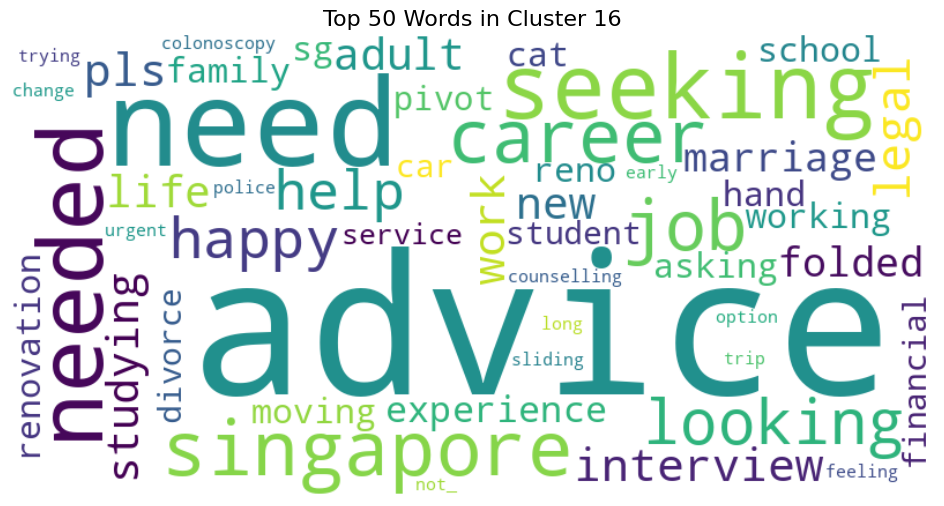

Visualizing Cluster 17


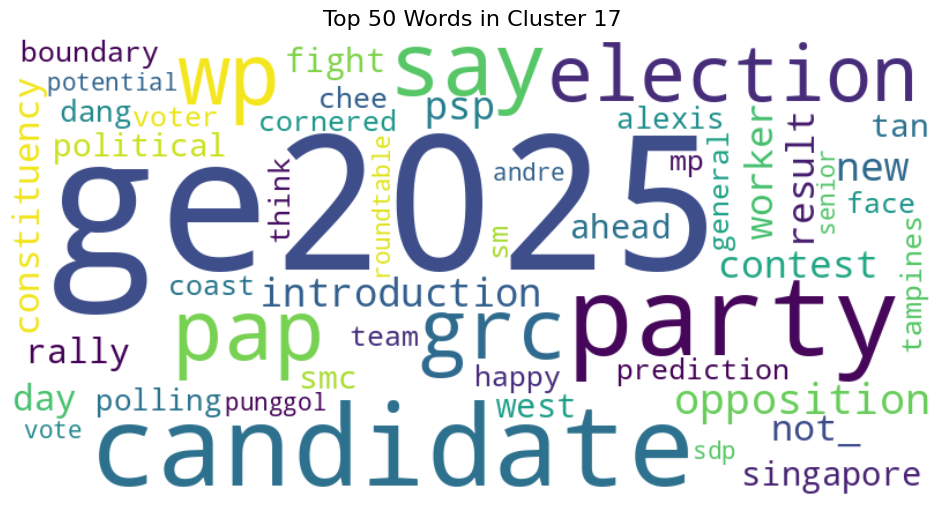

Visualizing Cluster 18


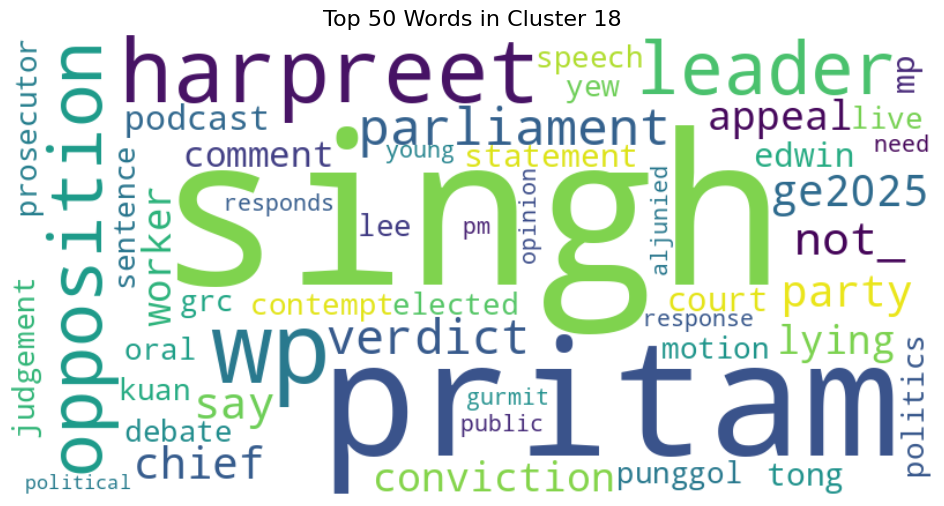

Visualizing Cluster 19


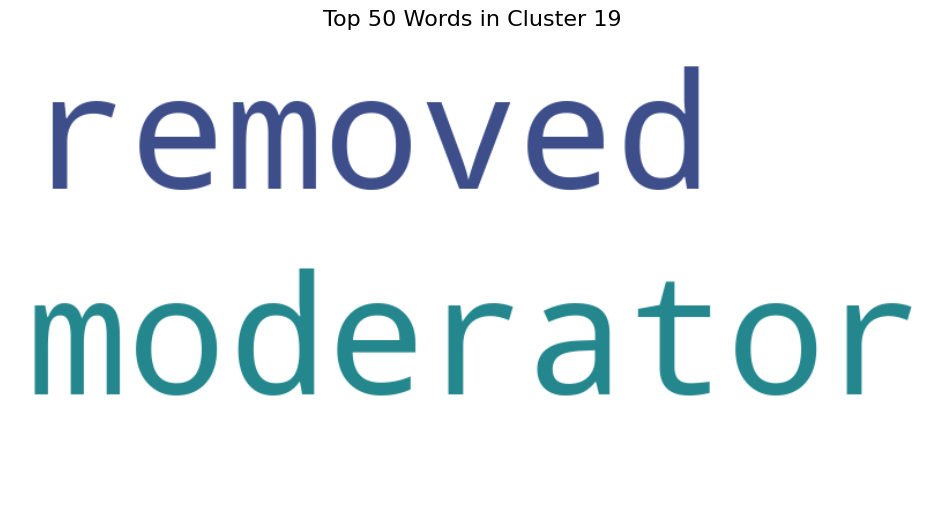

Visualizing Cluster 20


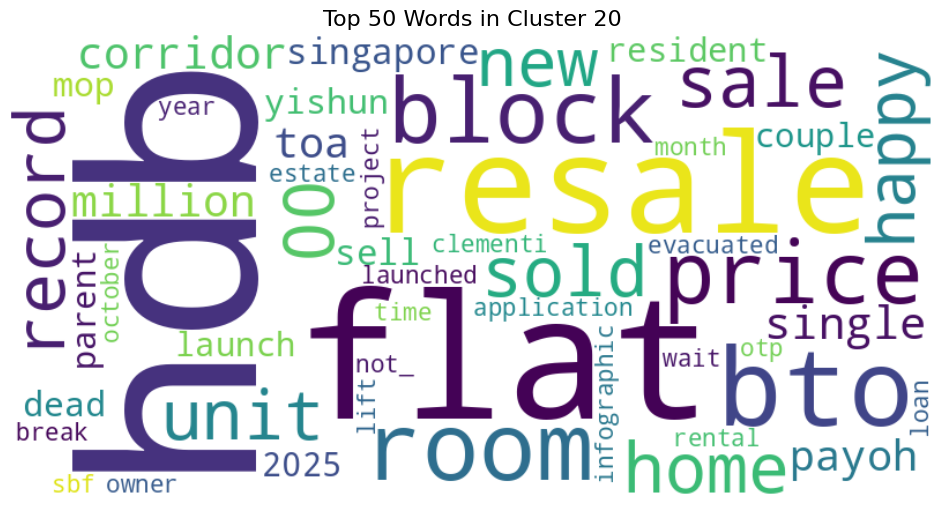

Visualizing Cluster 21


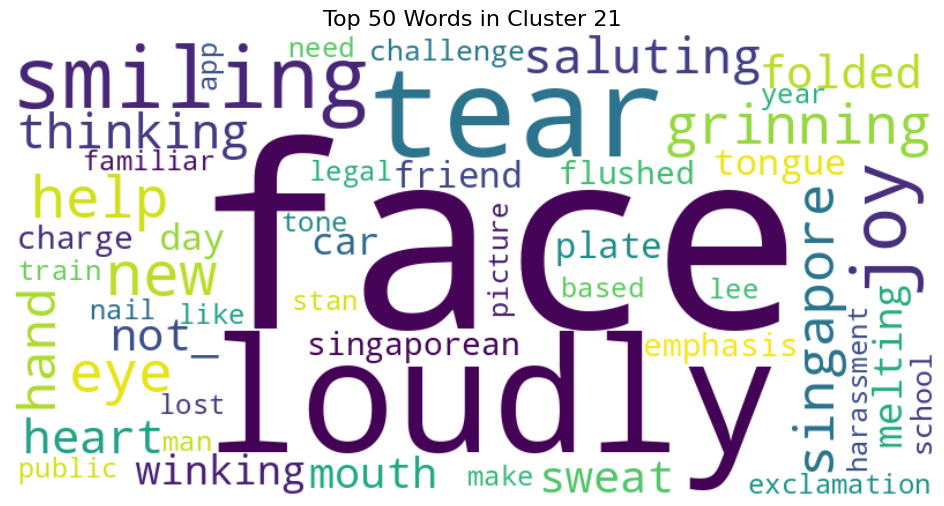

Visualizing Cluster 22


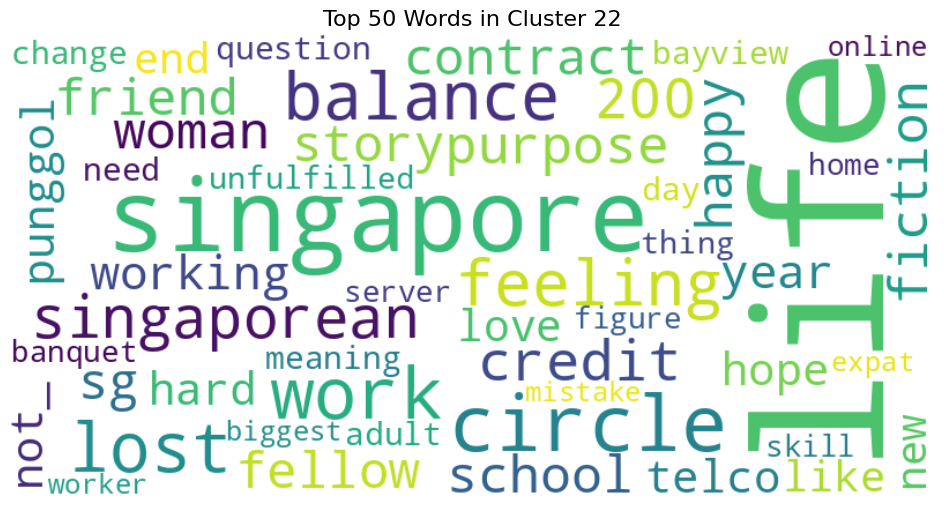

Visualizing Cluster 23


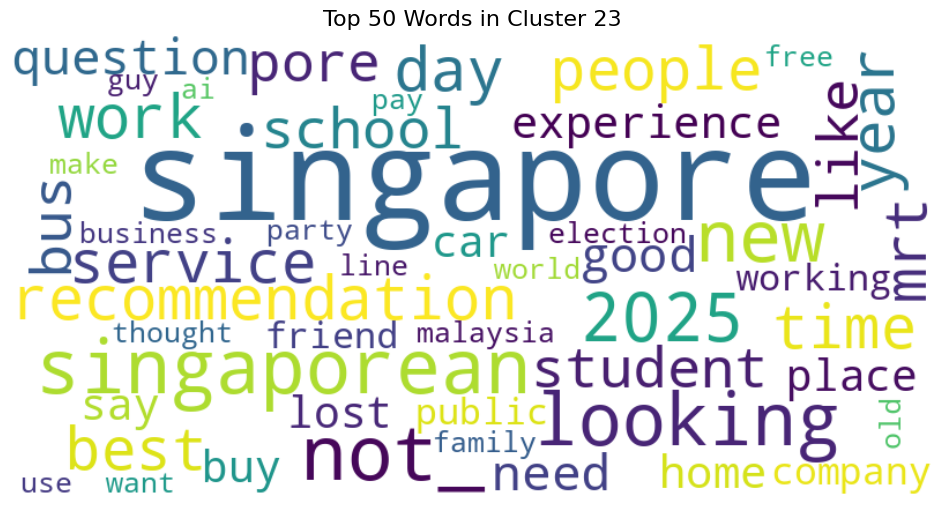

Visualizing Cluster 24


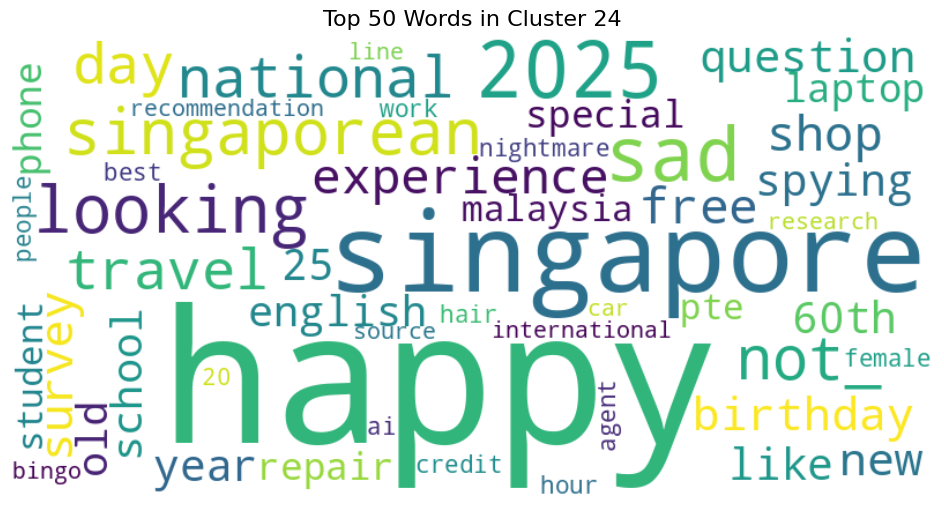

Visualizing Cluster 25


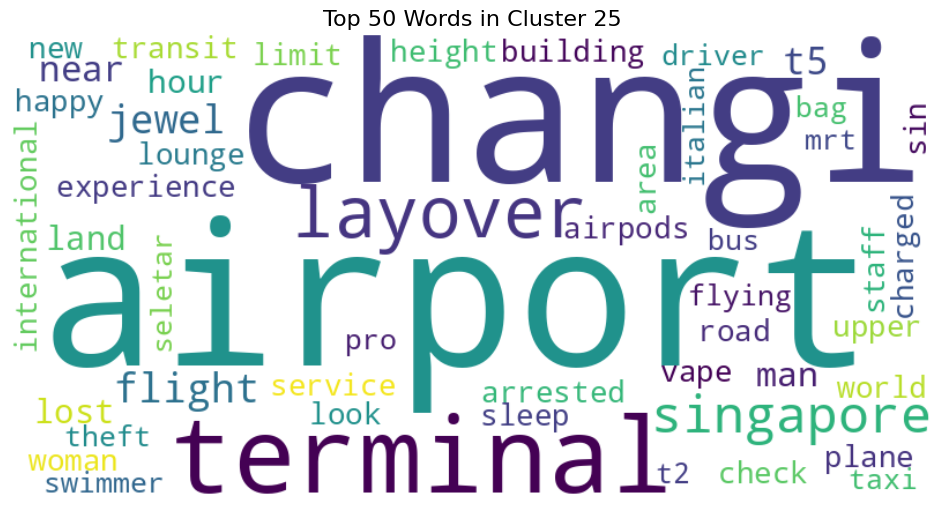

Visualizing Cluster 26


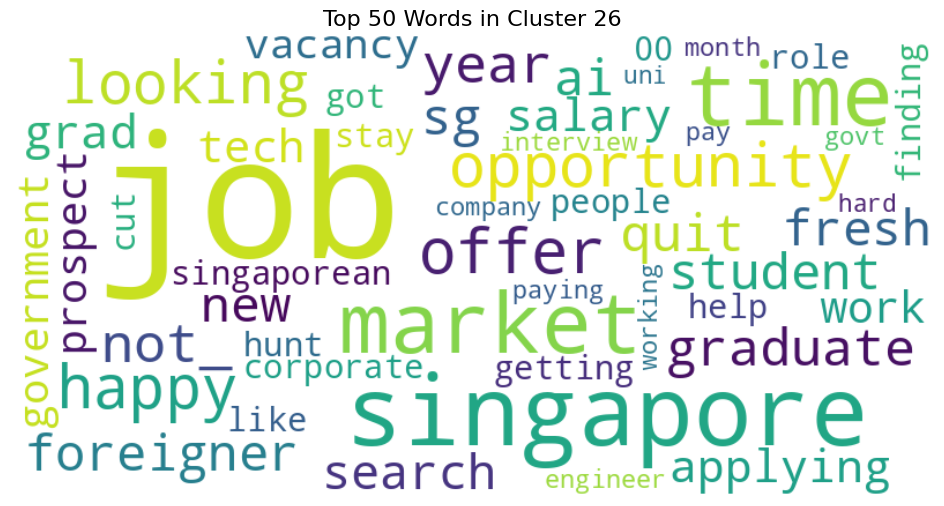

Visualizing Cluster 27


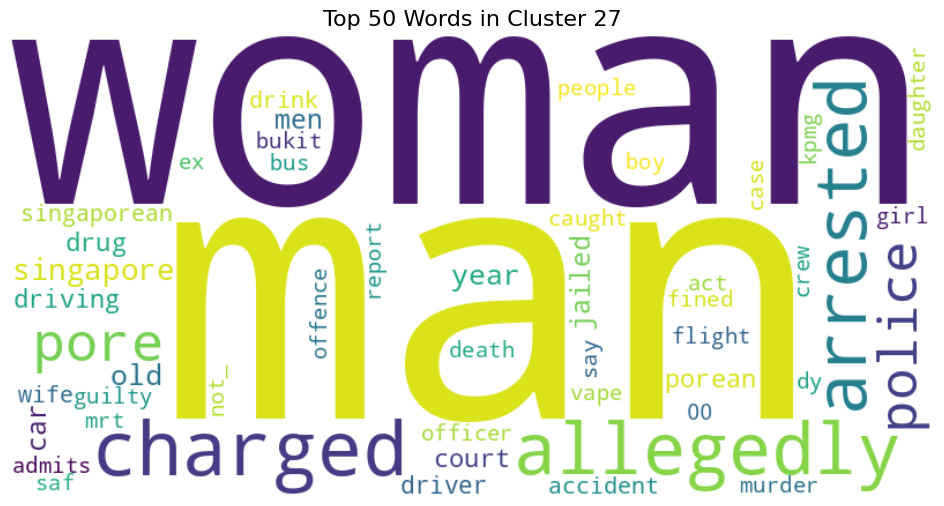

Visualizing Cluster 28


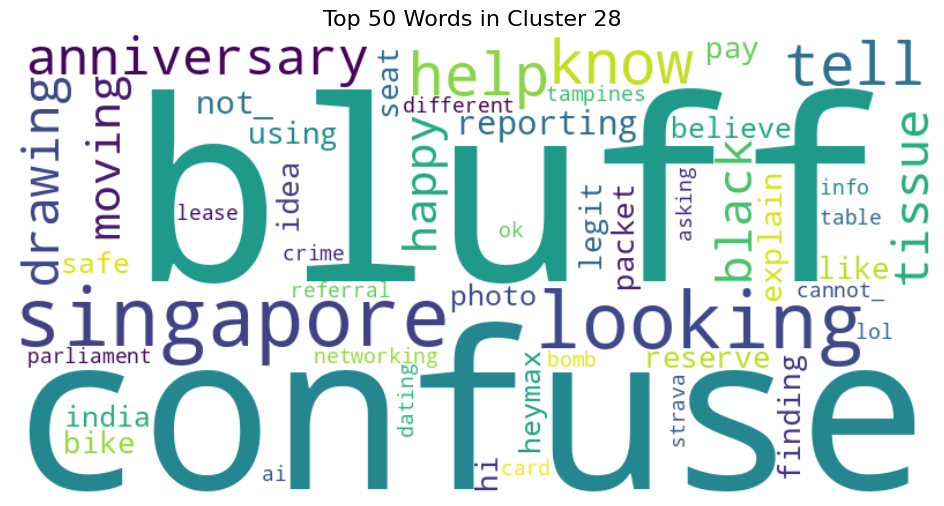

Visualizing Cluster 29


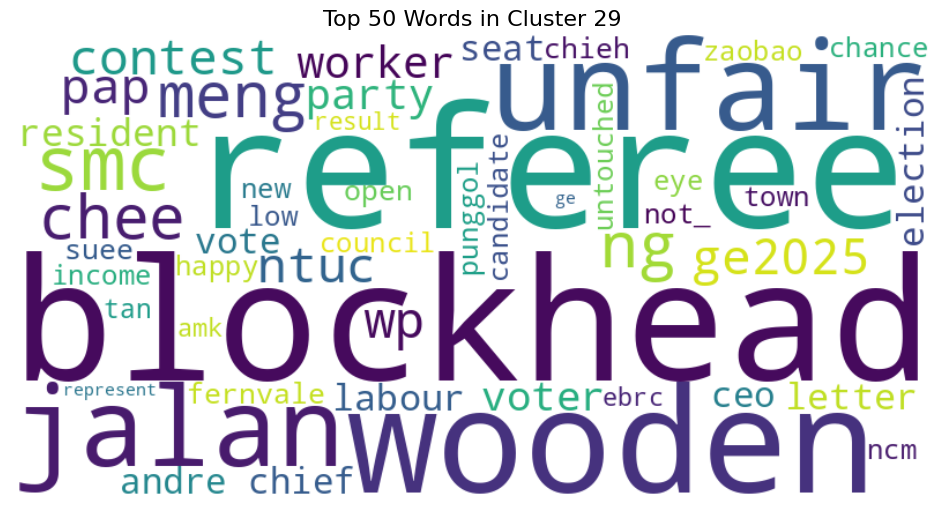

Visualizing Cluster 30


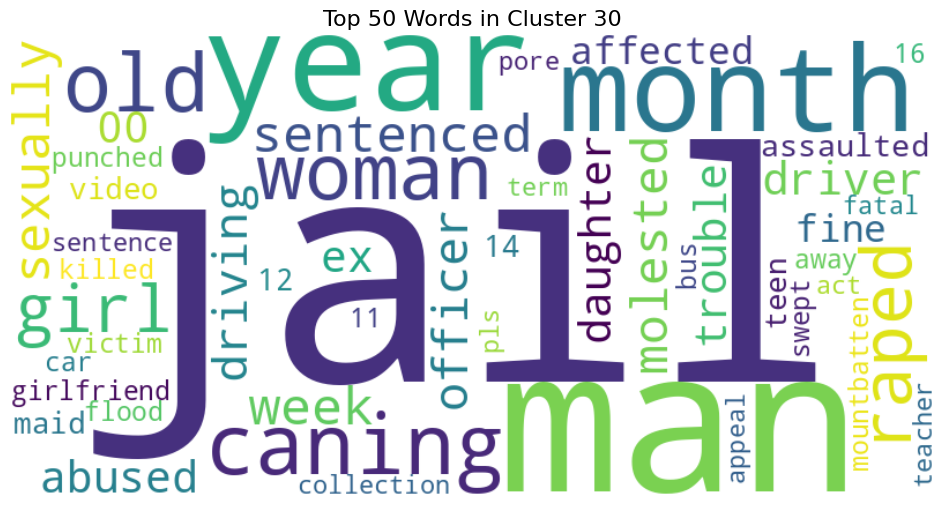

In [ ]:
generate_cluster_wordclouds(tfidf_full_text, tfidf_posts_vectorizer, labels=None, df=df_posts, cluster_col='bm25_cluster', top_n=50)

##### Keyword Extraction

In [ ]:
keywords_dict = get_cluster_keywords(tfidf_full_text, tfidf_posts_vectorizer, labels=None, df=df_posts, cluster_col='bm25_cluster', n_top_words=10)

Extracting top 10 keywords per cluster...
----------------------------------------
Cluster 0:
  Keywords: voucher, cdc, sg60, gst, household, singaporean, scheme, climate, cash, buy
----------------------------------------
Cluster 1:
  Keywords: pap, grc, wp, vote, psp, ge2025, candidate, party, opposition, mp
----------------------------------------
Cluster 2:
  Keywords: know, singapore, experience, sg, tried, happy, experienced, interested, want, like
----------------------------------------
Cluster 3:
  Keywords: not_, happy, singapore, like, time, year, people, day, think, know
----------------------------------------
Cluster 4:
  Keywords: singapore, sailor, lion, happy, year, city, day, million, win, week
----------------------------------------
Cluster 5:
  Keywords: tariff, singapore, let, trump, say, sg, student, singaporean, china, help
----------------------------------------
Cluster 6:
  Keywords: cheeky, mischievous, singapore, not_, job, scammed, sg, happy, like, possibl

### Document Bert

#### Load Data

In [ ]:
# --------------------
# Load Bert Embeddings
# --------------------
bert_titles = np.load('/content/drive/MyDrive/CS5246Project/data/vector_database/bert_titles_embeddings.npy')
bert_contents = np.load('/content/drive/MyDrive/CS5246Project/data/vector_database/bert_contents_embeddings.npy')
bert_full_text = np.load('/content/drive/MyDrive/CS5246Project/data/vector_database/bert_fulltext_embeddings.npy')

bert_comments = np.load('/content/drive/MyDrive/CS5246Project/data/vector_database/bert_comments_embeddings.npy')

# -------------------------------
# Load PostVault and CommentVault
# -------------------------------
df_posts = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/PostVault.csv', keep_default_na=False)
df_comments = pd.read_csv('/content/drive/MyDrive/CS5246Project/data/CommentVault.csv', keep_default_na=False)

# ---------------
# Load Bert Model
# ---------------
bert_model_path = os.path.join(models_dir, 'sentence_bert_model')
bert_model = SentenceTransformer(bert_model_path)

print("-----------------------------------------------")
print("Bert for posts and comments loaded successfully")
print("-----------------------------------------------")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

-----------------------------------------------
Bert for posts and comments loaded successfully
-----------------------------------------------


In [ ]:
print("------")
print("Titles")
print("------")
print("Shape:", bert_titles.shape)
print()
print("--------")
print("Contents")
print("--------")
print("Shape:", bert_contents.shape)
print()
print("---------")
print("Full Text")
print("---------")
print("Shape:", bert_full_text.shape)
print()
print("---------------")
print("Posts DataFrame")
print("---------------")
print("Shape:", df_posts.shape)

------
Titles
------
Shape: (31957, 384)

--------
Contents
--------
Shape: (31957, 384)

---------
Full Text
---------
Shape: (31957, 384)

---------------
Posts DataFrame
---------------
Shape: (31957, 36)


#### Dimensionality Reduction

To reduce the original high-dimensional space, we apply Truncated SVD. This technique is well-suited for sparse representations such as TF-IDF, as it captures the main directions of variation (latent components) and projects the data into a lower-dimensional dense space. In NLP, this approach is also known as Latent Semantic Analysis (LSA).

The goal is to retain most of the meaningful structure in the data while dramatically reducing dimensionality. This step is important because t-SNE does not operate efficiently on sparse matrices, and directly converting TF-IDF into a dense representation would be computationally and memory intensive. Truncated SVD makes the process feasible by compressing the feature space (for example, from ~100,000 dimensions down to 50–100), enabling t-SNE to run effectively and efficiently.

##### Explained Variance Ratio

We check the explained variance ratio first because it helps us understand how much information each SVD component retains. BM25 matrices are very high-dimensional and sparse, so not all components contribute equally. By examining the cumulative explained variance, we can choose a reasonable number of components that capture most of the important variance while keeping the data small enough for efficient t-SNE computation. This ensures that our t-SNE visualization preserves meaningful structure without unnecessary computation or memory usage.

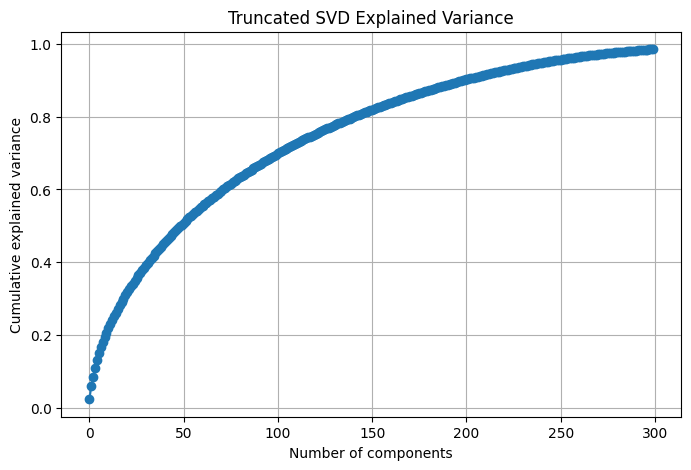

In [ ]:
# SVD Posts
# ---------
svd_posts = TruncatedSVD(n_components=300, random_state=42)
svd_posts.fit(bert_full_text)

# Explained Variance Ratio
explained_ratio = svd_posts.explained_variance_ratio_
cumulative_ratio = np.cumsum(explained_ratio)

# Plot Cumulative Variance
plt.figure(figsize=(8,5))
plt.plot(cumulative_ratio, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Truncated SVD Explained Variance")
plt.grid(True)
plt.show()

# SVD Comments
# ------------
# svd_comments = TruncatedSVD(n_components=600, random_state=42)
# svd_comments.fit(bm25_comments)

##### Truncated SVD

In [ ]:
# SVD Posts
# ---------
svd_posts = TruncatedSVD(n_components=150, random_state=42)

bert_titles_reduced = svd_posts.fit_transform(bert_titles)
bert_contents_reduced = svd_posts.fit_transform(bert_contents)
bert_full_text_reduced = svd_posts.fit_transform(bert_full_text)

# SVD Comments
# ------------
# svd_comments = TruncatedSVD(n_components=50, random_state=42)
# tfidf_comments_reduced = svd_comments.fit_transform(tfidf_comments)

#### Clustering

##### Silhouette Score

BM25 vectors are inherently sparse and directional, with each vector representing a document in a high-dimensional space. L2 normalization places all vectors on the unit hypersphere, emphasizing their direction rather than magnitude. Cosine distance, which measures the angle between vectors rather than their length, is therefore more appropriate for comparing documents: two documents with similar word distributions but different lengths will have a small cosine distance. In contrast, Euclidean distance can be misleading, as it is sensitive to magnitude differences rather than actual content similarity. As a result, using the silhouette score with cosine distance provides a more meaningful evaluation of clustering quality for text, better reflecting the semantic similarity between documents and the cohesion and separation of clusters.

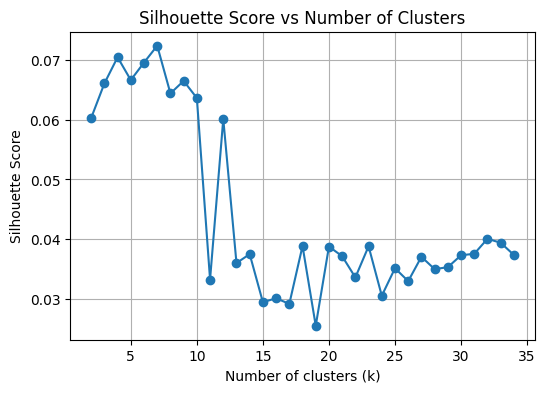

In [ ]:
sil_scores = []
# n_components = 150, n = 33, 0.122
k_values = range(2, 35)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(bert_full_text_reduced)

    # Silhouette Score
    # ----------------
    # Use cosine metric because BM25 vectors are directional
    score = silhouette_score(bert_full_text_reduced, labels, metric='cosine')
    sil_scores.append(score)

# ----
# Plot
# ----
plt.figure(figsize=(6,4))
plt.plot(k_values, sil_scores, marker='o')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

##### K-Means Clustering

In [ ]:
posts_cluster_labels = get_kmeans_labels(bert_full_text_reduced, n_clusters=7, random_state=42)

# ------------
# Write Labels
# ------------
print("Saving Labels to PostVault...")

assert len(df_posts) == len(posts_cluster_labels), \
    f"Size mismatch: df_posts={len(df_posts)}, labels={len(posts_cluster_labels)}"

df_posts['bert_cluster'] = posts_cluster_labels

save_single_df_to_csv(df_posts, "/content/drive/MyDrive/CS5246Project/data/", "PostVault")


-----------------------------------
K-Means Clustering (k=7) Completed
-----------------------------------
Shape of cluster labels: (31957,)
First 10 labels: [3 5 0 3 4 1 0 0 6 1]
Saving Labels to PostVault...
Saving DataFrames to '/content/drive/MyDrive/CS5246Project/data/' with name 'PostVault'...
----------------------------------------------------------------------------------------------------
PostVault saved to /content/drive/MyDrive/CS5246Project/data/PostVault.csv
----------------------------------------------------------------------------------------------------


#### Visualization

##### Stratified Sampling

We use stratified sampling because our dataset contains 31,923 entries, which would make running t-SNE computationally intensive. Stratified sampling allows us to reduce the dataset size while preserving the original class distribution.

In [ ]:
sampled_bert_full_text_reduced, _, sampled_posts_cluster_labels, _ = train_test_split(
    bert_full_text_reduced,
    posts_cluster_labels,
    test_size=0.9,                  # 10% for t-SNE
    stratify=posts_cluster_labels,  # stratified sampling
    random_state=42
)

print("-------------------------------")
print("Sampled Data Shape:", sampled_bert_full_text_reduced.shape)
print("-------------------------------")

-------------------------------
Sampled Data Shape: (3195, 150)
-------------------------------


##### t-SNE

In [ ]:
# ---------
# Full Data
# ---------
# full_text_tsne_3d = perform_tsne(bm25_full_text_reduced)

# ------------
# Sampled Data
# ------------
sampled_full_text_tsne_3d = perform_tsne(sampled_bert_full_text_reduced)

print("-----------------------------------------------------")
print("t-SNE 3D Dimensionality Reduction for Posts Completed")
print("-----------------------------------------------------")
print("Shape of posts_tsne_3d:", sampled_full_text_tsne_3d.shape)
print("First 5 rows of posts_tsne_3d:\n", sampled_full_text_tsne_3d[:5])

--------------------------------------------
t-SNE 3D Dimensionality Reduction Completed
--------------------------------------------
Shape of tsne_results: (3195, 3)
First 5 rows of tsne_results:
[[-34.581257  -11.055413   11.915875 ]
 [ -5.667011   41.522762    2.271464 ]
 [-27.139778   27.904123   12.999894 ]
 [ 11.265195   39.72498     6.264111 ]
 [-22.858612   33.66324     6.5443125]]
-----------------------------------------------------
t-SNE 3D Dimensionality Reduction for Posts Completed
-----------------------------------------------------
Shape of posts_tsne_3d: (3195, 3)
First 5 rows of posts_tsne_3d:
 [[-34.581257  -11.055413   11.915875 ]
 [ -5.667011   41.522762    2.271464 ]
 [-27.139778   27.904123   12.999894 ]
 [ 11.265195   39.72498     6.264111 ]
 [-22.858612   33.66324     6.5443125]]


##### Scatter Plot Visualization

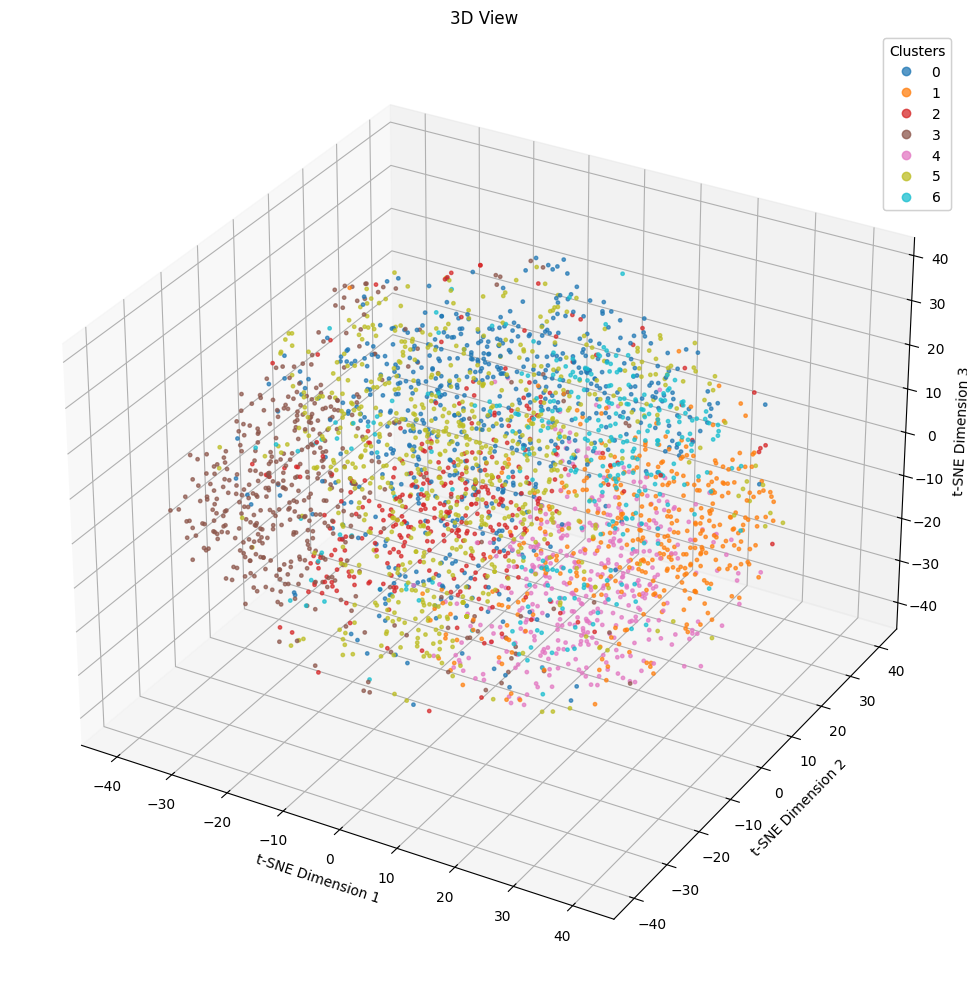

In [ ]:
# ---------
# Full Data
# ---------
# plot_scatter(full_text_tsne_3d, posts_cluster_labels, title="3D View")

# ------------
# Sampled Data
# ------------
plot_scatter(sampled_full_text_tsne_3d, sampled_posts_cluster_labels, title="3D View")

#### Data Analysis

##### Word Cloud

Visualizing Cluster 0


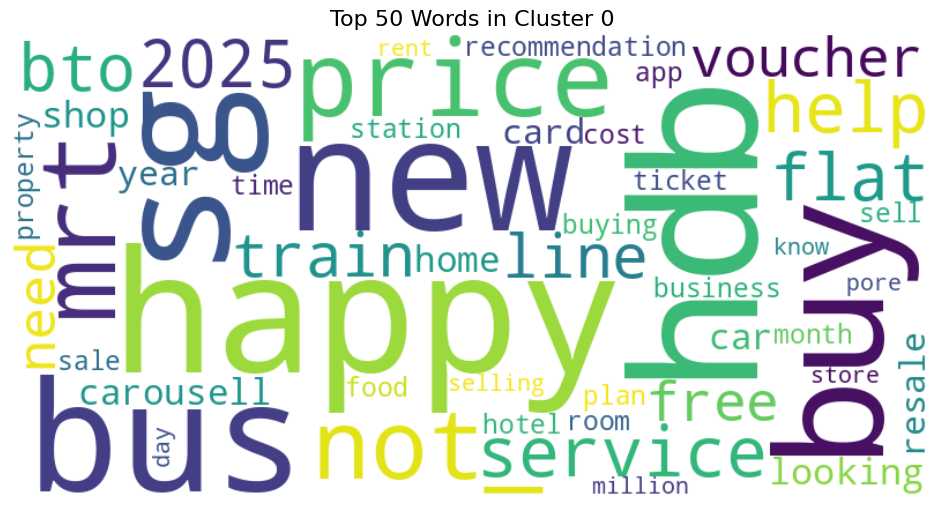

Visualizing Cluster 1


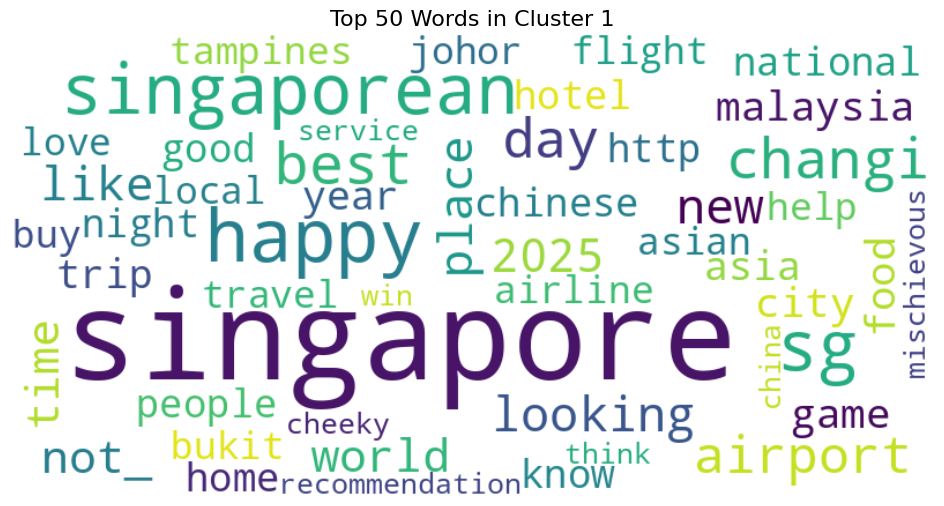

Visualizing Cluster 2


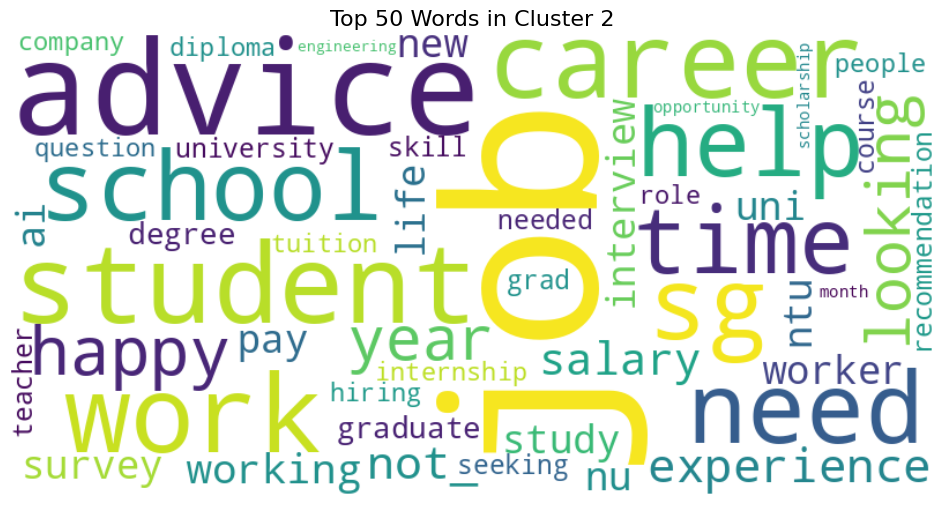

Visualizing Cluster 3


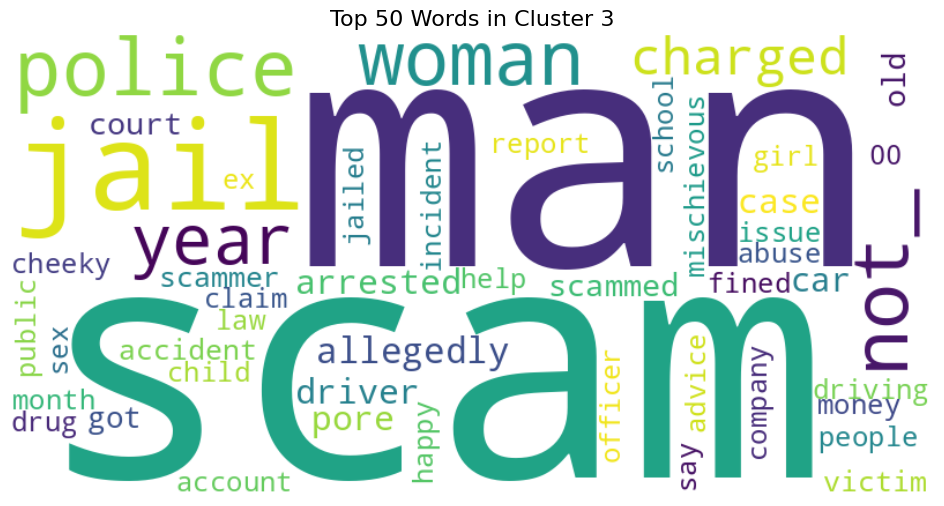

Visualizing Cluster 4


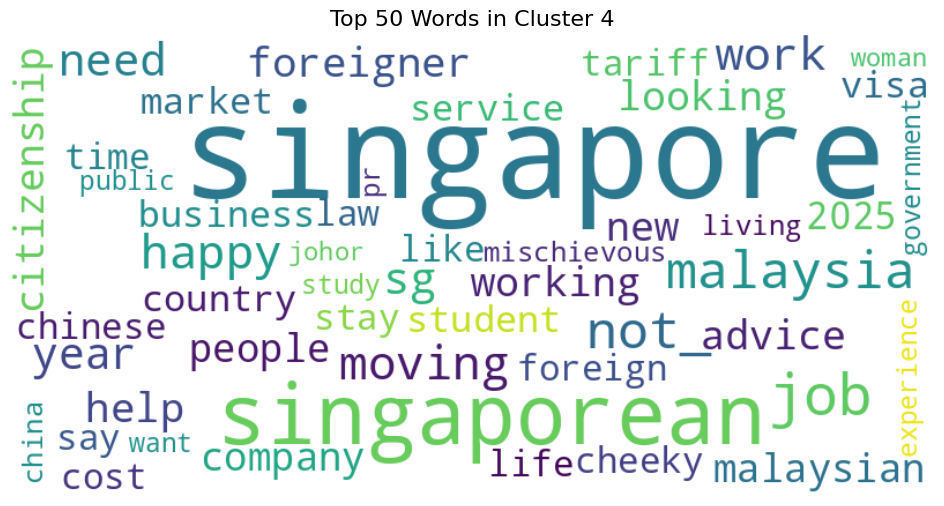

Visualizing Cluster 5


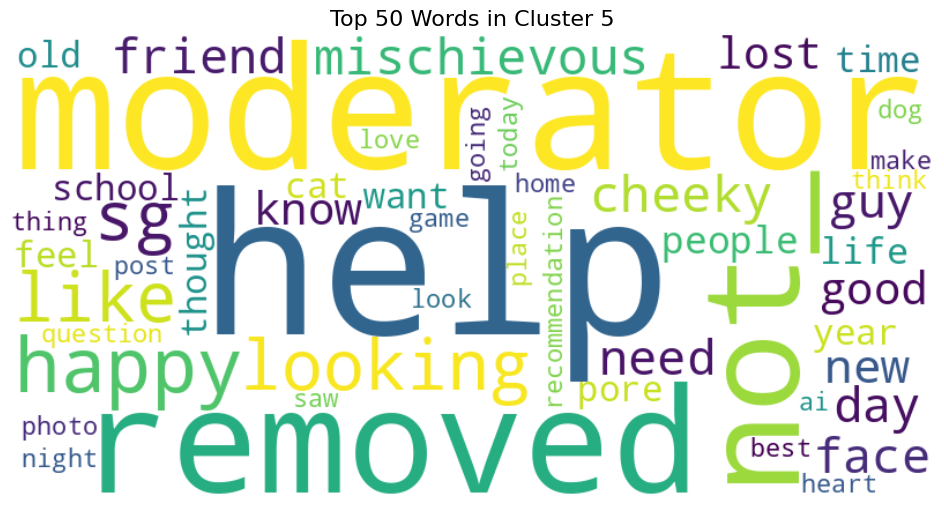

Visualizing Cluster 6


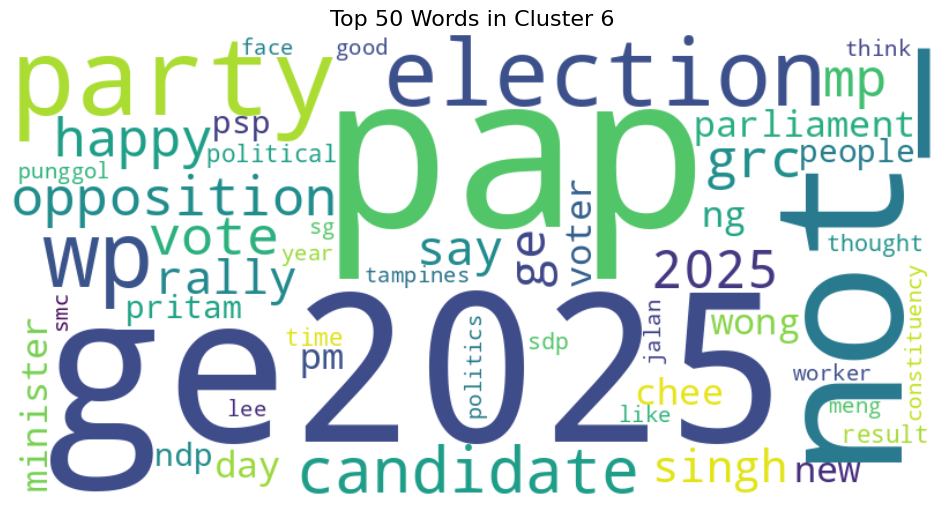

In [ ]:
generate_cluster_wordclouds(tfidf_full_text, tfidf_posts_vectorizer, labels=None, df=df_posts, cluster_col='bert_cluster', top_n=50)

##### Keyword Extraction

In [ ]:
keywords_dict = get_cluster_keywords(tfidf_full_text, tfidf_posts_vectorizer, labels=None, df=df_posts, cluster_col='bert_cluster', n_top_words=10)

Extracting top 10 keywords per cluster...
----------------------------------------
Cluster 0:
  Keywords: hdb, happy, sg, new, bus, buy, price, mrt, not_, service
----------------------------------------
Cluster 1:
  Keywords: singapore, happy, singaporean, sg, best, changi, day, airport, new, looking
----------------------------------------
Cluster 2:
  Keywords: job, advice, student, work, career, sg, need, school, help, time
----------------------------------------
Cluster 3:
  Keywords: scam, man, jail, police, not_, woman, year, charged, allegedly, pore
----------------------------------------
Cluster 4:
  Keywords: singapore, singaporean, job, malaysia, not_, happy, moving, work, need, sg
----------------------------------------
Cluster 5:
  Keywords: help, moderator, removed, not_, happy, looking, like, sg, cheeky, mischievous
----------------------------------------
Cluster 6:
  Keywords: pap, ge2025, not_, party, election, wp, candidate, opposition, vote, grc
-----------------